# MFG locacional em mercados de energia renovável

Este notebook estuda **onde** e **quanto** investir em geração solar no Sistema
Interligado Nacional. Um agente é pequeno e toma preços como dados; a população de
agentes, porém, determina a oferta agregada, o despacho, o congestionamento e os
preços que realimentam cada decisão.

A exposição separa objetos que têm funções diferentes:

1. **dados e fatos estilizados** — carga residual, CMO e captura de preço;
2. **clearing compartilhado** — rede, térmica em blocos, curtailment explícito e
   reservatório com estado $S_t$;
3. **laboratório finito** — incumbente e entrante solar;
4. **benchmark estático** — escolha contínua de capacidade com localização fixa;
5. **planejador social** — capacidade e despacho escolhidos conjuntamente;
6. **MFG dinâmico** — Bellman, capacidade, realocação, equação forward e clearing
   fechados em um único ponto fixo.

CMO observado, PLD e preço-sombra $\lambda$ permanecem distintos. O ótimo social é
resolvido independentemente da decisão privada. Um resultado só recebe o rótulo de
equilíbrio certificado quando o resíduo do operador **antes da relaxação** satisfaz
as tolerâncias declaradas.


## 0. Setup, imports e configuração

In [25]:
from __future__ import annotations

import json
import math
import time
import warnings
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140,
    "axes.titleweight": "bold",
    "axes.spines.right": False, "axes.spines.top": False,
    "font.size": 10,
})

SEED = 42
np.random.seed(SEED)

YEAR = 2025
SUBSYS_ORDER = ["SE", "S", "NE", "N"]
SUB_LABEL = {"N": "Norte", "NE": "Nordeste", "SE": "Sudeste/CO", "S": "Sul"}
SUB_COLOR = {"N": "#1f77b4", "NE": "#d62728", "SE": "#2ca02c", "S": "#9467bd"}
LOCS = SUBSYS_ORDER
N_LOC = len(LOCS)
HOURS = 24

def find_project_root(start: Path | None = None, marker: str = "validate_model") -> Path:
    cur = Path(start or Path.cwd()).resolve()
    for cand in [cur, *cur.parents]:
        if (cand / marker).exists():
            return cand
    return cur

ROOT = find_project_root()
OUT = ROOT / "outputs"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
CACHE_DIR = OUT / "cache"
for d in (OUT, TABLE_DIR, FIG_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"ROOT : {ROOT}")
print(f"CVXPY: {cp.__version__} | solvers: {cp.installed_solvers()[:6]}...")

ROOT : C:\Users\jvillas\Mean-Field-Games-in-Renewable-Energy
CVXPY: 1.7.5 | solvers: ['CLARABEL', 'OSQP', 'SCIPY', 'SCS']...


### Parâmetros de velocidade e do modelo

Mantidos em um único lugar para facilitar o ajuste fino. Para o ano modelado,
o custo de déficit é o valor oficial de 2025, R$ 8.327,76/MWh ([CCEE,
Comunicado 999/24](https://www.ccee.org.br/en/web/guest/-/co-divulgacao-do-custo-de-deficit-e-memoria-de-calculo-referente-ao-ano-2025)).
O valor da água usa R$ 250/MWh como cenário central e deve ser testado na faixa
R$ 80–500/MWh, pois varia com estação e hidrologia. Não há uma penalidade única
de curtailment que possa ser copiada para o despacho: as compensações dependem
da causa do corte e do contrato. Por isso, o valor de R$ 8/MWh foi substituído
por um epsilon de desempate, sem interpretação regulatória ([MME, Consulta Pública
210/2025](https://www.gov.br/mme/pt-br/assuntos/noticias/mme-abre-consulta-publica-para-solucionar-os-impactos-de-cortes-de-geracao-sobre-energias-renovaveis)).

In [26]:
# --- velocidade e certificação do benchmark estático
N_REP_DAYS = None
REP_DAY_CANDIDATES = range(4, 13)
MAX_ITER = 260
MAX_ITER_CALIB = 110
BISECTION_STEPS = 9
TOL_R_FP = 5e-3
TOL_C_FP = 5e-3
TOL_M_FP = 5e-4
STATIC_RELAXATION = 0.06

# O benchmark estático usa relaxação com passo estritamente positivo. O passo
# não tende a zero, pois a convergência será certificada pelo resíduo não
# relaxado BR(m)-m, e não pela pequena variação entre duas iteradas.
KM_SHIFT = 4.0
ALPHA_MIN, ALPHA_MAX = STATIC_RELAXATION, STATIC_RELAXATION

# --- tipos de agente 
AGENT_TYPES = ["high", "low"]
TYPE_WEIGHT = {"high": 0.45, "low": 0.55}
TYPE_PROD = {"high": 1.08, "low": 0.94}
TYPE_COST_MULT = {"high": 0.94, "low": 1.08}

# --- grade numérica do benchmark estático
K0_BIN = 160
K_MAX_BIN = 480
K_BINS = np.arange(K_MAX_BIN + 1)
N_K = len(K_BINS)
GAMMA_CAP_RS_MW2 = 5.24

# --- parâmetros físicos/econômicos do clearing 
PARAMS = {
    "deficit_penalty": 8327.76,
    "curtail_penalty_solar": 0.01,
    "curtail_penalty_wind": 0.01,
    "water_opportunity_cost": 250.0,
    "hydro_energy_scale": 1.00,
    "reservoir_hours": 8.0,
    "reservoir_initial_fraction": 0.50,
    # Cada medoide representa um regime recorrente. S_24=S_0 impede que o
    # modelo produza energia minerando artificialmente o estoque inicial.
    "reservoir_cyclic": True,
    "thermal_cost_mult": 1.00,
    "thermal_quad": 2e-4,
    "thermal_ramp_penalty": 2e-3,
    "transmission_mult": 1.00,
    "demand_scale": 1.00,
    "wind_scale": 1.00,
    "clearing_tikhonov": 1e-2,
}

RUN_SOCIAL_PLANNER = True
WATER_VALUE_RANGE = (80.0, 500.0)
TAU_MULT = 0.00

# --- MFG dinâmico integrado 
DYN_HORIZON = 6
DYN_BETA = 0.95
DYN_CAP_UNIT_MW = 93.0
DYN_MAX_BIN = 12
DYN_DELTA_BINS = (-1, 0, 1)
DYN_TAU_RS = 100_000_000.0 
DYN_ADJUSTMENT_RS_MW2 = 2_000.0
DYN_MOVE_COST_RS = 500_000_000.0
DYN_ENTRY_COST_RS = 20_000_000.0
DYN_CONCENTRATION_RS = 5_000_000.0
DYN_RELAXATION = 0.10
DYN_MAX_ITER = 100
DYN_TOL_M = 2e-4
DYN_TOL_C = 5e-3
DYN_TOL_R = 5e-3

print("Configuração carregada: clearing intertemporal + benchmark estático + MFG dinâmico.")


Configuração carregada: clearing intertemporal + benchmark estático + MFG dinâmico.


## 1. Dados — painel horário do SIN e o CMO

Carregamos o cache `outputs/cache/panel_hourly_v4.parquet` (geração e carga
horárias por subsistema, construído por `00_construcao_painel.ipynb`). 

Convenção de notação:
- `CMO_obs` — **Custo Marginal de Operação** observado/divulgado pelo ONS, em
  R\$/MWh. Não é o preço de liquidação.
- PLD — **Preço de Liquidação das Diferenças**, o preço do mercado de curto prazo;
  esta base não contém PLD observado.
- `lambda` — preço-sombra (dual) produzido pelos modelos de otimização. É um sinal
  de preço endógeno do clearing acadêmico, não CMO nem PLD observado.

In [27]:
def canonical_subsys(x: Any) -> str | None:
    s = str(x).strip().upper()
    mp = {
        "N": "N", "NORTE": "N",
        "NE": "NE", "NORDESTE": "NE",
        "SE": "SE", "SUDESTE": "SE", "SUDESTE/CO": "SE", "SUDESTE-CENTRO-OESTE": "SE",
        "S": "S", "SUL": "S",
    }
    return mp.get(s, s if s in SUBSYS_ORDER else None)


def add_calendar(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["din_instante"] = pd.to_datetime(out["din_instante"], errors="coerce")
    out["data"] = out["din_instante"].dt.date.astype(str)
    out["hora"] = out["din_instante"].dt.hour
    out["mes"] = out["din_instante"].dt.month
    out["fim_semana"] = out["din_instante"].dt.dayofweek.isin([5, 6]).astype(int)
    return out


def load_panel() -> pd.DataFrame:
    for p in [CACHE_DIR / "panel_hourly_v4.parquet", CACHE_DIR / "panel_hourly.parquet"]:
        if p.exists():
            print(f"Lendo painel: {p.name}")
            return pd.read_parquet(p)
    raise FileNotFoundError(
        "Painel não encontrado. Rode antes 00_construcao_painel.ipynb "
        "(esperado: outputs/cache/panel_hourly_v4.parquet)."
    )


panel = load_panel().copy()
panel["din_instante"] = pd.to_datetime(panel["din_instante"], errors="coerce")
panel = panel[(panel["din_instante"] >= f"{YEAR}-01-01") & (panel["din_instante"] < f"{YEAR+1}-01-01")].copy()
panel["id_subsistema"] = panel["id_subsistema"].map(canonical_subsys)
panel = panel[panel["id_subsistema"].isin(SUBSYS_ORDER)].copy()
panel = add_calendar(panel)

# --- mapeamento de colunas canônicas
def first_existing(cols: list[str]) -> str | None:
    return next((c for c in cols if c in panel.columns), None)

COLS = {
    "L":          first_existing(["L_global", "L_RB", "D", "demanda", "val_carga"]),
    "G_solar_obs": first_existing(["G_s_all", "G_s_centralizada", "gs", "G_solar", "solar"]),
    "G_wind_obs":  first_existing(["G_w_total", "gr", "G_eolica", "eolica"]),
    "G_hydro_obs": first_existing(["G_h_total", "gh", "G_hidro", "hidro"]),
    "G_therm_obs": first_existing(["G_th_total", "g_th_obs", "termica"]),
    "G_nuc_obs":   first_existing(["G_nuc_inflex", "g_nuc_obs", "nuclear"]),
}
missing = [k for k, v in COLS.items() if v is None and k != "G_nuc_obs"]
if missing:
    raise RuntimeError(f"Colunas essenciais ausentes: {missing}. Disponíveis: {list(panel.columns)}")

for dest, src in COLS.items():
    panel[dest] = pd.to_numeric(panel[src], errors="coerce").fillna(0.0) if src else 0.0

print("Mapeamento de colunas:", {k: v for k, v in COLS.items()})

Lendo painel: panel_hourly_v4.parquet
Mapeamento de colunas: {'L': 'D', 'G_solar_obs': 'gs', 'G_wind_obs': 'gr', 'G_hydro_obs': 'gh', 'G_therm_obs': 'g_th_obs', 'G_nuc_obs': 'g_nuc_obs'}


### 1.1 Junção do CMO por hora e subsistema

Fazemos um *left join* do painel com a tabela de CMO nas chaves
`(din_instante, id_subsistema)`. Isso apenas acrescenta a coluna `CMO_obs`; não
mistura CMO com carga, geração ou com o preço-sombra do modelo.

In [28]:
def merge_cmo(panel_in: pd.DataFrame) -> pd.DataFrame:
    out = panel_in.copy()
    cmo_path = CACHE_DIR / "cmo_hourly_v4.parquet"
    if not cmo_path.exists():
        print("AVISO: cache de CMO não encontrado; CMO_obs ficará NaN.")
        out["CMO_obs"] = np.nan
        return out

    cmo = pd.read_parquet(cmo_path)
    cmo["din_instante"] = pd.to_datetime(cmo["din_instante"], errors="coerce")
    cmo["id_subsistema"] = cmo["id_subsistema"].map(canonical_subsys)
    price_col = "cmo_h" if "cmo_h" in cmo.columns else next(c for c in cmo.columns if "cmo" in c.lower())

    out = out.merge(cmo[["din_instante", "id_subsistema", price_col]],
                    on=["din_instante", "id_subsistema"], how="left")
    out["CMO_obs"] = pd.to_numeric(out[price_col], errors="coerce")
    out = out.drop(columns=[price_col])
    # única lacuna (1 dia) -> preenche dentro de cada subsistema, sem vazar entre eles
    out["CMO_obs"] = out.groupby("id_subsistema")["CMO_obs"].transform(lambda s: s.ffill().bfill())
    return out


frac_nan_antes = float("nan") if "CMO_obs" not in panel.columns else panel["CMO_obs"].isna().mean()
panel = merge_cmo(panel)
panel = panel.sort_values(["id_subsistema", "din_instante"]).reset_index(drop=True)

print(f"CMO_obs: fração NaN após o merge = {panel['CMO_obs'].isna().mean():.4f}")
print("CMO_obs médio por subsistema (R$/MWh):")
print(panel.groupby("id_subsistema")["CMO_obs"].mean().round(2).to_string())

CMO_obs: fração NaN após o merge = 0.0000
CMO_obs médio por subsistema (R$/MWh):
id_subsistema
N     162.79
NE    150.61
S     226.58
SE    216.19


### 1.2 Avaliação do painel — cobertura e sanidade

Uma auditoria rápida: quantas horas por subsistema, fração de `NaN`, e as médias das séries que alimentam o modelo. O objetivo é mostrar que a base está completa e que **`CMO_obs` agora está populado**.

In [29]:
model_cols = ["L", "G_solar_obs", "G_wind_obs", "G_hydro_obs", "G_therm_obs", "G_nuc_obs", "CMO_obs"]

# Auditoria de cobertura: horas, dias e NaN por subsistema.
audit = (panel.groupby("id_subsistema")
         .agg(n_horas=("din_instante", "size"),
              n_dias=("data", "nunique"),
              ini=("din_instante", "min"),
              fim=("din_instante", "max"))
         .reindex(SUBSYS_ORDER))
audit["%NaN_CMO"] = (panel.groupby("id_subsistema")["CMO_obs"]
                     .apply(lambda s: 100 * s.isna().mean()).round(3))
print("Cobertura do painel:")
print(audit.to_string())

# Médias por subsistema das séries do modelo (MW, exceto CMO em R$/MWh).
print("\nMédias por subsistema (MW; CMO em R$/MWh):")
print(panel.groupby("id_subsistema")[model_cols].mean().round(1).to_string())

# Sanidade do preço: o CMO deve subir quando a carga residual sobe.
panel["L_res"] = panel["L"] - panel["G_solar_obs"] - panel["G_wind_obs"]
corr = panel.groupby("id_subsistema").apply(
    lambda g: g["CMO_obs"].corr(g["L_res"]), include_groups=False)
print("\nCorrelação CMO_obs × carga residual (esperado > 0):")
print(corr.round(3).to_string())

Cobertura do painel:
               n_horas  n_dias        ini                 fim  %NaN_CMO
id_subsistema                                                          
SE                8760     365 2025-01-01 2025-12-31 23:00:00       0.0
S                 8760     365 2025-01-01 2025-12-31 23:00:00       0.0
NE                8760     365 2025-01-01 2025-12-31 23:00:00       0.0
N                 8760     365 2025-01-01 2025-12-31 23:00:00       0.0

Médias por subsistema (MW; CMO em R$/MWh):
                     L  G_solar_obs  G_wind_obs  G_hydro_obs  G_therm_obs  G_nuc_obs  CMO_obs
id_subsistema                                                                                
N               8311.7        583.5       212.4       7578.6       2200.7        0.0    162.8
NE             13266.9       3341.2     12266.5       3228.6        771.2        0.0    150.6
S              13804.4       1301.0       698.8       8293.5       1065.2        0.0    226.6
SE             44225.9       5257

### 1.3 Painel consolidado (gravação)

Regravamos o painel com `CMO_obs` embutido. A partir daqui, qualquer notebook pode ler o preço diretamente.

Painel consolidado salvo: C:\Users\jvillas\Mean-Field-Games-in-Renewable-Energy\outputs\cache\panel_hourly_v4_consolidated.parquet
  35,040 linhas × 14 colunas


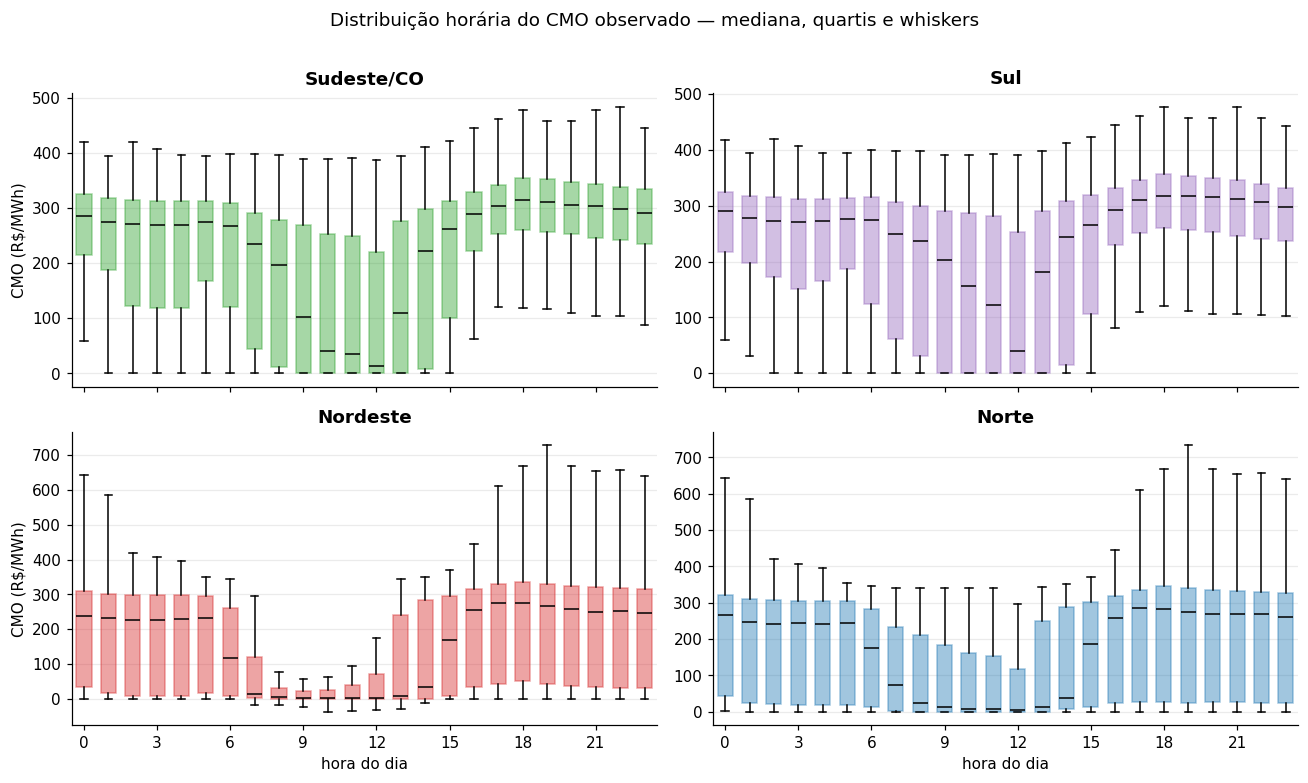

In [30]:
consolidated_path = CACHE_DIR / "panel_hourly_v4_consolidated.parquet"
keep = ["din_instante", "id_subsistema", "data", "hora", "mes", "fim_semana", *model_cols, "L_res"]
panel_consolidated = panel[keep].copy()
panel_consolidated.to_parquet(consolidated_path, index=False)
print(f"Painel consolidado salvo: {consolidated_path}")
print(f"  {len(panel_consolidated):,} linhas × {panel_consolidated.shape[1]} colunas")

# Distribuição horária do CMO: box-plots preservam mediana, quartis e caudas.
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, s in zip(axes.ravel(), SUBSYS_ORDER):
    sub = panel[panel["id_subsistema"] == s]
    values = [pd.to_numeric(sub.loc[sub["hora"] == h, "CMO_obs"], errors="coerce").dropna().to_numpy()
              for h in range(24)]
    bp = ax.boxplot(values, positions=range(24), widths=0.62, showfliers=False,
                    patch_artist=True, medianprops={"color": "black", "lw": 1.0})
    for box in bp["boxes"]:
        box.set(facecolor=SUB_COLOR[s], alpha=0.42, edgecolor=SUB_COLOR[s])
    ax.set_title(SUB_LABEL[s]); ax.grid(axis="y", alpha=0.25)
    ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels(range(0, 24, 3))
axes[1, 0].set_xlabel("hora do dia"); axes[1, 1].set_xlabel("hora do dia")
axes[0, 0].set_ylabel("CMO (R$/MWh)"); axes[1, 0].set_ylabel("CMO (R$/MWh)")
fig.suptitle("Distribuição horária do CMO observado — mediana, quartis e whiskers", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "cmo_perfil_horario_boxplot.png", bbox_inches="tight")
plt.show()

## 2. Capacidades proxy (p99) e custos anualizados

Para manter o notebook independente de bases adicionais de capacidade, usamos o
**percentil 99 da geração observada** (`p99`) como proxy operacional da
capacidade efetiva de cada fonte/subsistema. O custo anualizado do solar combina
CAPEX, conexão e O&M, anualizado por um fator de recuperação de capital (FRC).

In [31]:
def q99(x: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce").dropna()
    return float(np.nanquantile(x, 0.99)) if len(x) else 0.0


K_eff = (panel.groupby("id_subsistema")
         .agg(K_solar_p99=("G_solar_obs", q99), K_wind_p99=("G_wind_obs", q99),
              K_hydro_p99=("G_hydro_obs", q99), K_therm_p99=("G_therm_obs", q99),
              K_nuc_p99=("G_nuc_obs", q99))
         .reindex(SUBSYS_ORDER).fillna(0.0))

K_SOLAR_OBS = {s: max(float(K_eff.loc[s, "K_solar_p99"]), 1.0) for s in SUBSYS_ORDER}
K_SOLAR_TOTAL_OBS = float(sum(K_SOLAR_OBS.values()))
K_WIND = {s: max(float(K_eff.loc[s, "K_wind_p99"]), 0.0) for s in SUBSYS_ORDER}
K_HYDRO = {s: max(float(K_eff.loc[s, "K_hydro_p99"]), 1.0) for s in SUBSYS_ORDER}
K_THERM = {s: max(float(K_eff.loc[s, "K_therm_p99"]), 1.0) for s in SUBSYS_ORDER}
K_NUC = {s: max(float(K_eff.loc[s, "K_nuc_p99"]), 0.0) for s in SUBSYS_ORDER}

# Custo anualizado do solar: (CAPEX + conexão)·FRC + O&M, por região.
WACC, LIFE = 0.08, 25
FRC = WACC * (1 + WACC) ** LIFE / ((1 + WACC) ** LIFE - 1)
capex_reg = {"N": 4.2, "NE": 3.6, "SE": 3.8, "S": 4.0}   # MM R$/MW
conn_reg = {"N": 0.40, "NE": 0.30, "SE": 0.15, "S": 0.22}
om_reg = {"N": 0.084, "NE": 0.072, "SE": 0.076, "S": 0.080}
q_base = {s: (capex_reg[s] + conn_reg[s]) * 1e6 * FRC + om_reg[s] * 1e6 for s in SUBSYS_ORDER}
q_type = {(s, th): q_base[s] * TYPE_COST_MULT[th] for s in SUBSYS_ORDER for th in AGENT_TYPES}

# Calibração da unidade de capacidade (1 bin = CAP_UNIT_MW) e da temperatura.
CAP_UNIT_MW = K_SOLAR_TOTAL_OBS / K0_BIN
# Custo convexo por bin derivado da curvatura em espaço de capacidade (invariante à grade).
GAMMA_BIN_DEFAULT = GAMMA_CAP_RS_MW2 * CAP_UNIT_MW ** 2
TAU = TAU_MULT * CAP_UNIT_MW * float(np.mean(list(q_base.values())))

K_eff.to_csv(TABLE_DIR / "capacidade_proxy_p99.csv")
print("K solar observada (proxy p99), GW:", {s: round(K_SOLAR_OBS[s] / 1000, 2) for s in SUBSYS_ORDER})
print(f"K solar total: {K_SOLAR_TOTAL_OBS/1000:.2f} GW | 1 bin = {CAP_UNIT_MW:.1f} MW | gamma_bin default = {GAMMA_BIN_DEFAULT/1e6:.3f} MM R$/bin²")
print("q_base (k R$/MW/ano):", {s: round(q_base[s] / 1000, 1) for s in SUBSYS_ORDER})

K solar observada (proxy p99), GW: {'SE': 19.08, 'S': 5.92, 'NE': 11.79, 'N': 2.28}
K solar total: 39.07 GW | 1 bin = 244.2 MW | gamma_bin default = 0.312 MM R$/bin²
q_base (k R$/MW/ano): {'SE': 446.0, 'S': 475.3, 'NE': 437.3, 'N': 514.9}


## 3. Dias representativos

Resolver o clearing para todos os dias a cada iteração do MFG seria caro. O número
de dias típicos não é fixado *a priori*: testamos de 4 a 12 clusters e combinamos
silhueta com cobertura de estação e regime de calendário. As variáveis de calendário
distinguem dia útil, fim de semana, feriado e férias/fim de ano; o Natal entra como
feriado quando dezembro está coberto pela amostra.

Cada centro é representado pelo **dia real mais próximo** (medoide). A tabela final
identifica a estação e o regime do medoide, além da composição dominante do cluster.
Os pesos observados são reescalados para 365 dias apenas para anualizar receitas;
essa extrapolação fica explícita quando a base cobre menos de um ano.

In [32]:
FERIADOS_2025 = {"2025-01-01", "2025-03-03", "2025-03-04", "2025-04-18",
                 "2025-04-21", "2025-05-01", "2025-06-19", "2025-09-07",
                 "2025-10-12", "2025-11-02", "2025-11-15", "2025-11-20",
                 "2025-12-25"}
SEASON_BY_MONTH = {12: "verao", 1: "verao", 2: "verao", 3: "outono",
                   4: "outono", 5: "outono", 6: "inverno", 7: "inverno",
                   8: "inverno", 9: "primavera", 10: "primavera", 11: "primavera"}


def calendar_metadata(dates) -> pd.DataFrame:
    ts = pd.to_datetime(pd.Index(dates))
    iso = ts.strftime("%Y-%m-%d")
    feriado = iso.isin(FERIADOS_2025)
    ferias = ts.month.isin([1, 7]) | ((ts.month == 12) & (ts.day >= 20))
    regime = np.select([feriado, ferias, ts.dayofweek >= 5],
                       ["feriado", "ferias_fim_ano", "fim_semana"], default="util")
    return pd.DataFrame({"date": iso, "season": pd.Series(ts.month).map(SEASON_BY_MONTH),
                         "day_type": regime})


def build_representative_days(panel_in: pd.DataFrame, n_days: int | None = None) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    daily = (panel_in.groupby(["data", "id_subsistema"], observed=False)
             .agg(L_mean=("L", "mean"), L_peak=("L", "max"),
                  solar_sum=("G_solar_obs", "sum"), wind_sum=("G_wind_obs", "sum"),
                  hydro_sum=("G_hydro_obs", "sum"), cmo_mean=("CMO_obs", "mean"))
             .reset_index())
    wide = daily.pivot(index="data", columns="id_subsistema").sort_index()
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.ffill().bfill().fillna(wide.median(numeric_only=True))
    meta = calendar_metadata(wide.index); meta.index = wide.index
    X_num = wide.to_numpy(float)
    X_num = (X_num - X_num.mean(0)) / (X_num.std(0) + 1e-9)
    X_cal = pd.get_dummies(meta[["season", "day_type"]], dtype=float).to_numpy()
    X = np.column_stack([X_num, 2.0 * X_cal])  # calendário tem peso explícito

    try:
        from sklearn.cluster import KMeans
        from sklearn.metrics import silhouette_score
        candidates = [int(n_days)] if n_days is not None else [k for k in REP_DAY_CANDIDATES if k < len(wide)]
        fitted, diagnostics = {}, []
        seasons_all = set(meta["season"]); regimes_all = set(meta["day_type"])
        for k in candidates:
            km = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(X)
            chosen = []
            for c in range(k):
                idx = np.flatnonzero(km.labels_ == c)
                chosen.append(idx[np.argmin(((X[idx] - km.cluster_centers_[c]) ** 2).sum(1))])
            rep_meta = meta.iloc[chosen]
            sil = float(silhouette_score(X, km.labels_)) if k > 1 else np.nan
            season_cov = len(set(rep_meta["season"])) / max(len(seasons_all), 1)
            regime_cov = len(set(rep_meta["day_type"])) / max(len(regimes_all), 1)
            selection_score = sil + 0.05 * (season_cov + regime_cov) - 0.002 * k
            diagnostics.append({"n_clusters": k, "silhouette": sil,
                                "season_coverage": season_cov, "day_type_coverage": regime_cov,
                                "coverage_score": min(season_cov, regime_cov),
                                "selection_score": selection_score})
            fitted[k] = (km, chosen)
        diag = pd.DataFrame(diagnostics).sort_values("n_clusters").reset_index(drop=True)
        # Primeiro maximiza a cobertura dos fenômenos; entre modelos quase empatados
        # (até 0,02 do melhor escore), escolhe o menor para preservar parcimônia.
        eligible = diag[np.isclose(diag["coverage_score"], diag["coverage_score"].max())]
        near_best = eligible[eligible["selection_score"] >= eligible["selection_score"].max() - 0.02]
        selected_k = int(near_best["n_clusters"].min())
        km, chosen = fitted[selected_k]
        rows, homogeneity_rows = [], []
        annualization = 365.0 / len(wide)
        for c, medoid_idx in enumerate(chosen):
            idx = np.flatnonzero(km.labels_ == c)
            cluster_meta = meta.iloc[idx]
            dom_season = cluster_meta["season"].value_counts(normalize=True)
            dom_day = cluster_meta["day_type"].value_counts(normalize=True)
            # Distância RMS nas variáveis operacionais padronizadas usadas no clustering.
            # Zero é o próprio medoide; valores maiores significam dias menos homogêneos.
            distance = np.sqrt(np.mean((X_num[idx] - X_num[medoid_idx]) ** 2, axis=1))
            rows.append({"date": wide.index[medoid_idx], "cluster": int(c),
                         "weight_days": float(len(idx) * annualization),
                         "season": meta.iloc[medoid_idx]["season"],
                         "day_type": meta.iloc[medoid_idx]["day_type"],
                         "cluster_profile": f"{dom_season.index[0]} ({dom_season.iloc[0]:.0%}); {dom_day.index[0]} ({dom_day.iloc[0]:.0%})",
                         "distance_mean_rms": float(distance.mean()),
                         "distance_p90_rms": float(np.quantile(distance, 0.90)),
                         "distance_max_rms": float(distance.max())})
            for member_idx, dist in zip(idx, distance):
                homogeneity_rows.append({"cluster": int(c), "date": wide.index[member_idx],
                                         "medoid_date": wide.index[medoid_idx],
                                         "distance_to_medoid_rms": float(dist),
                                         "is_medoid": bool(member_idx == medoid_idx)})
        out = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
        out.insert(0, "block", [f"D{i+1:02d}" for i in range(len(out))])
        homogeneity = pd.DataFrame(homogeneity_rows)
        homogeneity["block"] = homogeneity["cluster"].map(out.set_index("cluster")["block"])
    except Exception as e:
        print("Fallback sem sklearn:", repr(e))
        selected_k = int(n_days or 8); qs = np.linspace(0.05, 0.95, selected_k)
        score = wide.filter(like="L_peak").mean(1).rank(pct=True)
        chosen_dates = [(score - q).abs().idxmin() for q in qs]
        out = meta.loc[chosen_dates].reset_index(drop=True)
        out.insert(0, "block", [f"D{i+1:02d}" for i in range(selected_k)])
        out["cluster"] = range(selected_k); out["weight_days"] = 365.0 / selected_k
        out["cluster_profile"] = "fallback por quantil de pico de carga"
        diag = pd.DataFrame([{"n_clusters": selected_k, "silhouette": np.nan,
                              "season_coverage": np.nan, "day_type_coverage": np.nan,
                              "coverage_score": np.nan,
                              "selection_score": np.nan}])
        homogeneity = pd.DataFrame(columns=["cluster", "date", "medoid_date",
                                                "distance_to_medoid_rms", "is_medoid", "block"])
    assert np.isclose(out["weight_days"].sum(), 365.0), "Pesos anualizados devem somar 365."
    return out, diag, homogeneity


rep_days, rep_day_diagnostics, rep_day_homogeneity = build_representative_days(panel, N_REP_DAYS)
rep_days.to_csv(TABLE_DIR / "representative_days.csv", index=False)
rep_day_diagnostics.to_csv(TABLE_DIR / "representative_days_model_selection.csv", index=False)
rep_day_homogeneity.to_csv(TABLE_DIR / "representative_days_homogeneity.csv", index=False)
print("Seleção do número de dias típicos:")
print(rep_day_diagnostics.round(3).to_string(index=False))
print("\nCentros/medoides escolhidos e sua interpretação:")
print(rep_days.to_string(index=False))
print("\nHomogeneidade intracluster (distância RMS ao medoide nas variáveis padronizadas):")
print(rep_days[["block", "date", "weight_days", "distance_mean_rms",
                "distance_p90_rms", "distance_max_rms"]].round(3).to_string(index=False))
print("Soma dos pesos anualizados:", round(rep_days["weight_days"].sum(), 6))
calendar_all = calendar_metadata(sorted(panel["data"].unique()))
missing_seasons = sorted(set(calendar_all["season"]) - set(rep_days["season"]))
missing_day_types = sorted(set(calendar_all["day_type"]) - set(rep_days["day_type"]))
print("Fenômenos ausentes dos medoides selecionados:",
      {"estacoes": missing_seasons, "regimes_calendario": missing_day_types})
if missing_day_types:
    print("ATENÇÃO: aumentar k até", max(REP_DAY_CANDIDATES),
          "não necessariamente faz eventos raros virarem medoides; trate-os em sensibilidade separada.")

Seleção do número de dias típicos:
 n_clusters  silhouette  season_coverage  day_type_coverage  coverage_score  selection_score
          4       0.235              1.0               0.75            0.75            0.314
          5       0.225              1.0               0.75            0.75            0.303
          6       0.218              1.0               0.75            0.75            0.294
          7       0.219              1.0               0.75            0.75            0.293
          8       0.220              1.0               0.75            0.75            0.292
          9       0.227              1.0               0.75            0.75            0.297
         10       0.229              1.0               0.75            0.75            0.296
         11       0.240              1.0               0.75            0.75            0.306
         12       0.232              1.0               0.75            0.75            0.295

Centros/medoides escolhidos e sua 

### 3.1 Arrays do modelo `[dia, local, hora]`

Montamos os tensores de carga, geração e disponibilidade consumidos pelo clearing.
A hidrologia observada define o **volume de afluência diário proxy** de cada
medoide. Diferentemente de um simples orçamento de energia, o clearing agora possui
um estado explícito de reservatório:

$$S_{d,\ell,t+1}=S_{d,\ell,t}+A_{d,\ell,t}-h_{d,\ell,t}-v_{d,\ell,t}.$$

Como cada medoide representa um regime diário recorrente, usamos
$S_{d,\ell,24}=S_{d,\ell,0}$. Essa condição cíclica evita extrair gratuitamente o
estoque inicial e permite deslocar a água entre horas sem fingir uma cronologia
entre medoides. Uma extensão sazonal genuína exigiria cenários cronológicos, e não
centros de clusters.


In [33]:
def _day_matrix(date: str, col: str) -> np.ndarray:
    sub = panel[panel["data"] == str(date)]
    mat = np.zeros((N_LOC, HOURS), float)
    for i, s in enumerate(LOCS):
        g = sub[sub["id_subsistema"] == s].groupby("hora")[col].mean().reindex(range(HOURS))
        fb = panel[panel["id_subsistema"] == s].groupby("hora")[col].mean().reindex(range(HOURS))
        mat[i, :] = g.fillna(fb).ffill().bfill().fillna(0.0).to_numpy(float)
    return mat


D = len(rep_days)
weights = rep_days["weight_days"].to_numpy(float)
load = np.zeros((D, N_LOC, HOURS), float)
solar_obs = np.zeros_like(load)
wind_obs = np.zeros_like(load)
hydro_obs = np.zeros_like(load)
therm_obs = np.zeros_like(load)
nuc_obs = np.zeros_like(load)

for d, row in tqdm(list(rep_days.iterrows()), desc="montando arrays"):
    load[d] = _day_matrix(row["date"], "L")
    solar_obs[d] = _day_matrix(row["date"], "G_solar_obs")
    wind_obs[d] = _day_matrix(row["date"], "G_wind_obs")
    hydro_obs[d] = _day_matrix(row["date"], "G_hydro_obs")
    therm_obs[d] = _day_matrix(row["date"], "G_therm_obs")
    nuc_obs[d] = _day_matrix(row["date"], "G_nuc_obs")

cf_solar = np.zeros_like(solar_obs)
wind_avail = np.maximum(wind_obs, 0.0)
nuc_avail = np.maximum(nuc_obs, 0.0)
for i, s in enumerate(LOCS):
    cf_solar[:, i, :] = np.clip(
        solar_obs[:, i, :] / max(K_SOLAR_OBS[s], 1e-6), 0.0, 1.4)

# O volume afluente diário reproduz a energia hidro observada do medoide, mas a
# trajetória intra-diária passa pelo estado S. Afluência uniforme é uma proxy
# deliberada; o despacho decide quando turbinar e quando verter.
hydro_energy_budget = np.zeros((D, N_LOC), float)
for d in range(D):
    for i, s in enumerate(LOCS):
        hydro_energy_budget[d, i] = min(
            float(np.maximum(hydro_obs[d, i, :], 0.0).sum()) * PARAMS["hydro_energy_scale"],
            24.0 * K_HYDRO[s],
        )
hydro_inflow = np.repeat((hydro_energy_budget / HOURS)[:, :, None], HOURS, axis=2)
reservoir_capacity = np.array(
    [PARAMS["reservoir_hours"] * K_HYDRO[s] for s in LOCS], dtype=float)

print("Shapes -> load:", load.shape, "| cf_solar:", cf_solar.shape,
      "| hydro_inflow:", hydro_inflow.shape)
print("Peso anual total:", weights.sum())
print("Reservatório proxy (GWh-eq):",
      {s: round(reservoir_capacity[i] / 1000, 1) for i, s in enumerate(LOCS)})


montando arrays: 100%|██████████| 4/4 [00:00<00:00,  8.94it/s]

Shapes -> load: (4, 4, 24) | cf_solar: (4, 4, 24) | hydro_inflow: (4, 4, 24)
Peso anual total: 365.0
Reservatório proxy (GWh-eq): {'SE': np.float64(360.0), 'S': np.float64(121.9), 'NE': np.float64(52.3), 'N': np.float64(149.7)}


## 4. Clearing locacional compartilhado — formulação

Todas as camadas estratégicas chamam o mesmo operador físico. Dada a capacidade
solar por localização e tipo, ele transforma

$$K\longmapsto G^s(K)\longmapsto
(g^s,c^s,g^w,c^w,h,S,v,n,F,u,\lambda).$$

Isso evita comparar agentes privados e planejador sob despachos diferentes. A
oferta renovável, a dinâmica da água, a curva térmica, a rede e o déficit pertencem
ao primal; $\lambda$ é o dual do balanço. O laboratório finito, o benchmark
estático, o planejador e o MFG dinâmico variam apenas quem escolhe $K$ e como essa
escolha é realimentada.


### 4.1 Clearing locacional, curtailment e preço nodal

Dada a oferta solar de cada região, resolvemos um despacho convexo de 24 horas
para cada dia representativo. Há quatro nós físicos e o hub contábil $I$, com
topologia $I\leftrightarrow\{N,NE,SE\}$, $NE\leftrightarrow SE$ e $SE\leftrightarrow S$.

O curtailment é agora uma variável física explícita:

$$g^s_{d,\ell,t}+c^s_{d,\ell,t}=\bar g^s_{d,\ell,t},\qquad
g^w_{d,\ell,t}+c^w_{d,\ell,t}=\bar g^w_{d,\ell,t}.$$

O balanço é escrito como `carga − geração = 0`; portanto, seu próprio dual é
$\lambda=\partial V/\partial L$, sem correção de sinal. A térmica é uma curva de
mérito em três blocos, a hidro possui potência máxima e dinâmica de estoque, e os
fluxos respeitam limites de interface.

A condição $S_{24}=S_0$ é apropriada aos medoides recorrentes: o reservatório
desloca água entre horas, mas não cria energia ao terminar o dia vazio.


In [34]:
def safe_median_numeric(x: pd.Series, default: float) -> float:
    arr = pd.to_numeric(x, errors="coerce").dropna().to_numpy(float)
    return float(np.nanmedian(arr)) if len(arr) and np.isfinite(arr).any() else float(default)


def build_thermal_costs() -> tuple[np.ndarray, np.ndarray]:
    """Curva térmica reduzida em 3 blocos de mérito (50%/30%/20%).

    Os custos são proxies ancoradas no CMO mediano regional, não ofertas observadas
    de usinas individuais e tampouco o PLD.
    """
    fallback = {"N": 120.0, "NE": 110.0, "SE": 140.0, "S": 130.0}
    block_mult = np.array([0.80, 1.25, 1.85])
    cap_split = np.array([0.50, 0.30, 0.20])
    costs = np.zeros((N_LOC, 3)); caps = np.zeros((N_LOC, 3))
    for i, s in enumerate(LOCS):
        med = safe_median_numeric(panel.loc[panel["id_subsistema"] == s, "CMO_obs"], fallback[s])
        base = float(np.clip(med, 60.0, 450.0))
        costs[i, :] = base * block_mult
        caps[i, :] = max(K_THERM[s], 1.0) * cap_split
    return costs, caps


THERM_COST, THERM_CAP = build_thermal_costs()
N_BLOCKS_TH = THERM_COST.shape[1]

HUB = "I"
EDGES = [(HUB, "SE"), (HUB, "NE"), (HUB, "N"), ("NE", "SE"), ("SE", "S")]
N_EDGES = len(EDGES)
# Limites reduzidos de interface (MW); devem ser substituídos por limites horários
# do ONS em uma versão de rede mais detalhada.
FALLBACK_FMAX = {(HUB, "SE"): 8000.0, (HUB, "NE"): 8000.0,
                 (HUB, "N"): 4500.0, ("NE", "SE"): 8000.0,
                 ("SE", "S"): 6000.0}
FMAX = np.array([FALLBACK_FMAX[e] for e in EDGES]) * PARAMS["transmission_mult"]

print("Custo dos blocos térmicos (R$/MWh) — ancorado na mediana do CMO:")
print(pd.DataFrame(THERM_COST, index=LOCS, columns=["baixo", "médio", "alto"]).round(1).to_string())
print("Intercâmbio FMAX (MW):", {f"{o}-{d}": float(FMAX[k]) for k, (o, d) in enumerate(EDGES)})
print("Topologia: I<->{SE, NE, N}, NE<->SE e SE<->S; I é hub sem carga nem geração.")

Custo dos blocos térmicos (R$/MWh) — ancorado na mediana do CMO:
    baixo  médio   alto
SE  210.5  328.9  486.7
S   217.9  340.4  503.8
NE  104.7  163.7  242.2
N   140.1  219.0  324.1
Intercâmbio FMAX (MW): {'I-SE': 8000.0, 'I-NE': 8000.0, 'I-N': 4500.0, 'NE-SE': 8000.0, 'SE-S': 6000.0}
Topologia: I<->{SE, NE, N}, NE<->SE e SE<->S; I é hub sem carga nem geração.


### 4.2 Motor parametrizado de clearing (CVXPY parametrizado)

A classe monta o problema convexo uma vez e expõe `solve(K_by_type)`, que devolve despacho, preços nodais $\lambda$, receita por MW e tipo $R_{\ell,\theta}$ e diagnósticos.

In [35]:
class DispatchEngineCVX:
    def __init__(self, load, cf_solar, wind_avail, nuc_avail, hydro_inflow,
                 reservoir_capacity, weights, params):
        self.load = load.astype(float)
        self.cf_solar = cf_solar.astype(float)
        self.wind_avail_base = wind_avail.astype(float)
        self.nuc_avail = nuc_avail.astype(float)
        self.hydro_inflow = hydro_inflow.astype(float)
        self.reservoir_capacity = np.asarray(reservoir_capacity, float)
        self.weights = weights.astype(float)
        self.params = dict(params)
        self.D, self.L, self.T = self.load.shape
        self._build_problem()

    def _build_problem(self) -> None:
        D, L, T = self.D, self.L, self.T
        p = self.params
        self.solar_pot = cp.Parameter((D, L, T), nonneg=True, name="solar_potential")
        self.demand = cp.Parameter((D, L, T), nonneg=True, name="demand")
        self.wind_avail = cp.Parameter((D, L, T), nonneg=True, name="wind_avail")

        self.g_solar = cp.Variable((D, L, T), nonneg=True)
        self.curt_solar = cp.Variable((D, L, T), nonneg=True)
        self.g_wind = cp.Variable((D, L, T), nonneg=True)
        self.curt_wind = cp.Variable((D, L, T), nonneg=True)
        self.g_hydro = cp.Variable((D, L, T), nonneg=True)
        self.spill = cp.Variable((D, L, T), nonneg=True)
        self.storage = cp.Variable((D, L, T + 1), nonneg=True)
        self.g_th = cp.Variable((D, L, N_BLOCKS_TH, T), nonneg=True)
        self.deficit = cp.Variable((D, L, T), nonneg=True)
        self.flow = cp.Variable((D, N_EDGES, T))

        constraints = [
            self.g_solar + self.curt_solar == self.solar_pot,
            self.g_wind + self.curt_wind == self.wind_avail,
        ]
        self.balance_cons = {}
        objective = 0
        for d in range(D):
            w = float(self.weights[d])
            objective += w * p["curtail_penalty_solar"] * cp.sum(self.curt_solar[d])
            objective += w * p["curtail_penalty_wind"] * cp.sum(self.curt_wind[d])
            objective += w * p["deficit_penalty"] * cp.sum(self.deficit[d])
            objective += w * p["water_opportunity_cost"] * cp.sum(self.g_hydro[d])

            for i, s in enumerate(LOCS):
                s0 = float(p["reservoir_initial_fraction"] * self.reservoir_capacity[i])
                constraints += [
                    self.storage[d, i, :] <= self.reservoir_capacity[i],
                    self.storage[d, i, 0] == s0,
                    self.g_hydro[d, i, :] <= K_HYDRO[s],
                    self.storage[d, i, 1:] == self.storage[d, i, :-1]
                    + self.hydro_inflow[d, i, :] - self.g_hydro[d, i, :] - self.spill[d, i, :],
                ]
                if p.get("reservoir_cyclic", True):
                    constraints += [self.storage[d, i, -1] == s0]

                gth_total = cp.sum(self.g_th[d, i, :, :], axis=0)
                objective += w * p["thermal_ramp_penalty"] * cp.sum_squares(
                    gth_total[1:] - gth_total[:-1])
                for b in range(N_BLOCKS_TH):
                    constraints += [self.g_th[d, i, b, :] <= THERM_CAP[i, b]]
                    objective += w * THERM_COST[i, b] * p["thermal_cost_mult"] * cp.sum(
                        self.g_th[d, i, b, :])
                    objective += w * 0.5 * p["thermal_quad"] * cp.sum_squares(
                        self.g_th[d, i, b, :])

            for e_idx in range(N_EDGES):
                constraints += [
                    self.flow[d, e_idx, :] <= FMAX[e_idx],
                    self.flow[d, e_idx, :] >= -FMAX[e_idx],
                ]

            hub_net_import = 0
            for e_idx, (origin, destination) in enumerate(EDGES):
                if destination == HUB:
                    hub_net_import = hub_net_import + self.flow[d, e_idx, :]
                if origin == HUB:
                    hub_net_import = hub_net_import - self.flow[d, e_idx, :]
            constraints += [hub_net_import == 0]

            for i, loc in enumerate(LOCS):
                net_import = 0
                for e_idx, (origin, destination) in enumerate(EDGES):
                    if destination == loc:
                        net_import = net_import + self.flow[d, e_idx, :]
                    if origin == loc:
                        net_import = net_import - self.flow[d, e_idx, :]
                generation = (
                    self.g_solar[d, i, :] + self.g_wind[d, i, :]
                    + self.g_hydro[d, i, :] + cp.sum(self.g_th[d, i, :, :], axis=0)
                    + self.nuc_avail[d, i, :] + net_import + self.deficit[d, i, :]
                )
                con = self.demand[d, i, :] - generation == 0
                constraints += [con]
                self.balance_cons[(d, i)] = con

        tik = float(p.get("clearing_tikhonov", 0.0))
        if tik > 0:
            objective += tik * (
                cp.sum_squares(self.g_solar) + cp.sum_squares(self.g_wind)
                + cp.sum_squares(self.g_hydro) + cp.sum_squares(self.deficit)
                + cp.sum_squares(self.g_th)
            )
        self.problem = cp.Problem(cp.Minimize(objective), constraints)
        self.demand.value = np.maximum(self.load * p["demand_scale"], 0.0)
        self.wind_avail.value = np.maximum(self.wind_avail_base * p["wind_scale"], 0.0)

    def solar_potential_from_K(self, K_by_type):
        potential = np.zeros((self.D, self.L, self.T), float)
        for i, loc in enumerate(LOCS):
            k_effective = sum(
                float(K_by_type[loc].get(agent_type, 0.0)) * TYPE_PROD[agent_type]
                for agent_type in AGENT_TYPES)
            potential[:, i, :] = k_effective * self.cf_solar[:, i, :]
        return np.maximum(potential, 0.0)

    def solve(self, K_by_type, verbose: bool = False):
        self.solar_pot.value = self.solar_potential_from_K(K_by_type)
        solved, errors = False, []
        for solver, kwargs in [
            ("CLARABEL", {"max_iter": 1800}),
            ("OSQP", {"eps_abs": 1e-5, "eps_rel": 1e-5, "max_iter": 18000, "polishing": True}),
            ("SCS", {"eps": 1e-3, "max_iters": 9000}),
        ]:
            try:
                if solver in cp.installed_solvers():
                    self.problem.solve(solver=solver, warm_start=True, verbose=verbose, **kwargs)
                    if self.problem.status == "optimal":
                        solved = True
                        break
                    errors.append((solver, f"status={self.problem.status}"))
            except Exception as exc:
                errors.append((solver, repr(exc)))
        if not solved:
            raise RuntimeError(
                f"Clearing não resolveu. status={self.problem.status}; errors={errors}")

        gsol = np.maximum(np.asarray(self.g_solar.value, float), 0.0)
        csol = np.maximum(np.asarray(self.curt_solar.value, float), 0.0)
        gwind = np.maximum(np.asarray(self.g_wind.value, float), 0.0)
        cwind = np.maximum(np.asarray(self.curt_wind.value, float), 0.0)
        ghydro = np.maximum(np.asarray(self.g_hydro.value, float), 0.0)
        spill = np.maximum(np.asarray(self.spill.value, float), 0.0)
        storage = np.maximum(np.asarray(self.storage.value, float), 0.0)
        gth = np.maximum(np.asarray(self.g_th.value, float), 0.0)
        deficit = np.maximum(np.asarray(self.deficit.value, float), 0.0)
        potential = np.asarray(self.solar_pot.value, float)

        lam = np.zeros((self.D, self.L, self.T), float)
        for d in range(self.D):
            w = max(float(self.weights[d]), 1e-9)
            for i in range(self.L):
                raw = np.asarray(self.balance_cons[(d, i)].dual_value, float) / w
                lam[d, i, :] = np.where(np.abs(raw) < 1e-7, 0.0, raw)

        delivery = np.clip(
            np.divide(gsol, potential, out=np.ones_like(gsol), where=potential > 1e-6),
            0.0, 1.0)
        revenue_per_mw = {}
        for i, loc in enumerate(LOCS):
            for agent_type in AGENT_TYPES:
                cf_agent = self.cf_solar[:, i, :] * TYPE_PROD[agent_type]
                revenue_per_mw[(loc, agent_type)] = float(
                    np.sum(self.weights[:, None] * lam[:, i, :] * cf_agent * delivery[:, i, :]))

        reservoir_error = storage[:, :, 1:] - storage[:, :, :-1] - self.hydro_inflow + ghydro + spill
        diag_rows = []
        for d, row in rep_days.iterrows():
            for i, loc in enumerate(LOCS):
                diag_rows.append({
                    "block": row["block"], "date": row["date"],
                    "weight_days": float(self.weights[d]), "loc": loc,
                    "lambda_mean": float(lam[d, i, :].mean()),
                    "lambda_max": float(lam[d, i, :].max()),
                    "lambda_std": float(lam[d, i, :].std()),
                    "solar_curt_MWh_day": float(csol[d, i, :].sum()),
                    "wind_curt_MWh_day": float(cwind[d, i, :].sum()),
                    "deficit_MWh_day": float(deficit[d, i, :].sum()),
                    "thermal_MWh_day": float(gth[d, i, :, :].sum()),
                    "hydro_MWh_day": float(ghydro[d, i, :].sum()),
                    "spill_MWh_day": float(spill[d, i, :].sum()),
                    "storage_initial_MWh": float(storage[d, i, 0]),
                    "storage_final_MWh": float(storage[d, i, -1]),
                    "reservoir_balance_max_abs": float(np.max(np.abs(reservoir_error[d, i, :]))),
                })
        return {
            "status": self.problem.status, "objective": float(self.problem.value),
            "lambda": lam, "R": revenue_per_mw,
            "g_solar": gsol, "curt_solar": csol,
            "g_wind": gwind, "curt_wind": cwind,
            "g_hydro": ghydro, "g_th": gth, "spill": spill, "storage": storage,
            "flow": np.asarray(self.flow.value, float),
            "deficit": deficit, "solar_potential": potential, "delivery": delivery,
            "diagnostics": pd.DataFrame(diag_rows),
            "reservoir_balance_error": float(np.max(np.abs(reservoir_error))),
        }


engine = DispatchEngineCVX(
    load, cf_solar, wind_avail, nuc_avail, hydro_inflow,
    reservoir_capacity, weights, PARAMS)


def obs_K_by_type():
    return {
        s: {agent_type: K_SOLAR_OBS[s] * TYPE_WEIGHT[agent_type]
            for agent_type in AGENT_TYPES}
        for s in LOCS
    }


t0 = time.time()
clear_bench = engine.solve(obs_K_by_type())
print(f"Benchmark de 1 clearing: {time.time()-t0:.2f}s | status={clear_bench['status']}")
print(clear_bench["diagnostics"].groupby("loc")[[
    "lambda_mean", "lambda_max", "solar_curt_MWh_day", "spill_MWh_day"
]].mean().round(2).to_string())
print(f"Erro máximo da dinâmica do reservatório: {clear_bench['reservoir_balance_error']:.2e} MWh")

# Caminhos de S, afluência, turbinamento e vertimento para auditoria e para o notebook 08.
reservoir_rows = []
for d, rep in rep_days.iterrows():
    for i, loc in enumerate(LOCS):
        for hour in range(HOURS + 1):
            reservoir_rows.append({
                "block": rep["block"], "date": rep["date"], "loc": loc, "hour": hour,
                "storage_MWh": float(clear_bench["storage"][d, i, hour]),
                "inflow_MWh": float(hydro_inflow[d, i, hour]) if hour < HOURS else np.nan,
                "hydro_MWh": float(clear_bench["g_hydro"][d, i, hour]) if hour < HOURS else np.nan,
                "spill_MWh": float(clear_bench["spill"][d, i, hour]) if hour < HOURS else np.nan,
            })
reservoir_path = pd.DataFrame(reservoir_rows)
reservoir_path.to_csv(TABLE_DIR / "reservoir_state_path.csv", index=False)

# Sensibilidade ao custo de oportunidade da água.
water_rows = []
for water_value in [WATER_VALUE_RANGE[0], PARAMS["water_opportunity_cost"], WATER_VALUE_RANGE[1]]:
    p_water = dict(PARAMS)
    p_water["water_opportunity_cost"] = float(water_value)
    eng_water = DispatchEngineCVX(
        load, cf_solar, wind_avail, nuc_avail, hydro_inflow,
        reservoir_capacity, weights, p_water)
    cl_water = eng_water.solve(obs_K_by_type())
    dg = cl_water["diagnostics"]
    water_rows.append({
        "water_value_RS_MWh": water_value,
        "lambda_mean_RS_MWh": float(np.average(
            dg["lambda_mean"], weights=dg["weight_days"])),
        "hydro_MWh_weighted": (dg["hydro_MWh_day"] * dg["weight_days"]).sum(),
        "spill_MWh_weighted": (dg["spill_MWh_day"] * dg["weight_days"]).sum(),
        "thermal_MWh_weighted": (dg["thermal_MWh_day"] * dg["weight_days"]).sum(),
    })
water_sensitivity = pd.DataFrame(water_rows)
water_sensitivity.to_csv(TABLE_DIR / "water_value_sensitivity.csv", index=False)
print("\nSensibilidade ao valor da água:")
print(water_sensitivity.round(2).to_string(index=False))


Benchmark de 1 clearing: 0.65s | status=optimal
     lambda_mean  lambda_max  solar_curt_MWh_day  spill_MWh_day
loc                                                            
N         271.89      272.48                 0.0        49634.7
NE        274.96      276.44                 0.0            0.0
S         275.34      276.49                 0.0            0.0
SE        274.97      276.49                 0.0        23041.9
Erro máximo da dinâmica do reservatório: 4.39e-11 MWh

Sensibilidade ao valor da água:
 water_value_RS_MWh  lambda_mean_RS_MWh  hydro_MWh_weighted  spill_MWh_weighted  thermal_MWh_weighted
               80.0              241.53        390273558.37          5317527.74           80231896.41
              250.0              277.04        372962137.53         22628948.58           97543317.23
              500.0              504.27        328527165.40         67063920.71          141978289.44



### 4.3 Do modelo físico ao clearing em energia equivalente — primal, dual e KKT

Em uma usina individual $j$, a conversão física começa em

$$P^h_{j,t}=\eta_{j,t}\,\rho^w g\,H^{net}_{j,t}\,Q^{tur}_{j,t},$$

com

$$H^{net}_{j,t}=Z^{mon}_j(V_{j,t})-
Z^{jus}_j(Q^{tur}_{j,t}+Q^{spill}_{j,t})-H^{loss}_{j,t}.$$

O notebook não pretende reproduzir cada curva cota-volume-vazão do SIN. Ele agrega
essas conversões em **energia equivalente**: $h_{d,\ell,t}=P^h_{d,\ell,t}\Delta t$
e $A_{d,\ell,t}$ já são medidos em MWh-equivalentes. Por isso o coeficiente de
conversão da dinâmica reduzida é um; não se está afirmando que altura de queda e
rendimento físicos sejam constantes por usina.

Para capacidades solares dadas, o operador compartilhado resolve, esquematicamente,

$$\min \sum_d p_d\sum_{\ell,t}\left[
\sum_b c_{\ell b}n_{d,\ell,b,t}
+\frac{\varepsilon_n}{2}n_{d,\ell,b,t}^2
+\pi_h h_{d,\ell,t}+\pi_s c^s_{d,\ell,t}
+\pi_w c^w_{d,\ell,t}+\pi_u u_{d,\ell,t}\right]
+\text{penalidade de rampa},$$

sujeito a

$$g^s+c^s=\bar g^s(K),\qquad g^w+c^w=\bar g^w,$$

$$S_{t+1}=S_t+A_t-h_t-v_t,\quad 0\le S_t\le\bar S,
\quad 0\le h_t\le\bar H,\quad S_{24}=S_0,$$

limites dos blocos térmicos, limites bilaterais de fluxo, conservação no hub $I$ e
o balanço nodal escrito como

$$L_{d,\ell,t}-g^s_{d,\ell,t}-g^w_{d,\ell,t}-h_{d,\ell,t}
-\sum_b n_{d,\ell,b,t}-g^{nuc}_{d,\ell,t}
-F^{net}_{d,\ell,t}-u_{d,\ell,t}=0.$$

Se $\lambda$ multiplica esse último balanço, o teorema do envelope dá

$$\lambda_{d,\ell,t}=\frac{\partial V^*}{\partial L_{d,\ell,t}}.$$

Esse sinal é auditado numericamente: aumentar a carga em uma unidade não pode
reduzir o custo ótimo em um problema de despacho monotônico. Para um bloco térmico
interior, a estacionariedade iguala $\lambda$ ao custo marginal do bloco, incluindo
o termo quadrático e a derivada da penalidade de rampa. Quando $u>0$, a
complementaridade leva $\lambda$ ao custo de déficit $\pi_u$.

Para entender o corte renovável, seja $\nu^s$ o dual de
$g^s+c^s-\bar g^s=0$. Em um ponto interior de geração,
$-\lambda+\nu^s=0$; se $c^s>0$, então $\pi_s+\nu^s=0$. Logo,
$\lambda=-\pi_s$ quando geração e corte são simultaneamente marginais. O
curtailment não é um resíduo calculado depois: pertence ao primal e satisfaz KKT.

Finalmente, se $\mu_t$ multiplica
$S_{t+1}-S_t-A_t+h_t+v_t=0$, a condição interior da hidro é

$$\lambda_t=\pi_h+\mu_t,$$

enquanto a estacionariedade de $S_t$ transporta $\mu$ entre horas e acrescenta os
multiplicadores das bandas quando o estoque toca piso ou teto. Essa é a conta que
transforma água hoje em flexibilidade futura. A tabela abaixo audita a dinâmica,
o fechamento cíclico e as grandezas usadas nas seções seguintes.


,block,loc,storage_initial_MWh,storage_final_MWh,hydro_MWh_day,spill_MWh_day,reservoir_balance_max_abs,cyclic_gap_MWh
0,D01,SE,179987.8222,179987.8222,839306.0632,58903.6248,0.0,0.0
1,D01,S,60970.3307,60970.3307,228561.7258,0.0002,0.0,0.0
2,D01,NE,26165.7149,26165.7149,70578.4138,0.0002,0.0,0.0
3,D01,N,74860.8801,74860.8801,217365.6571,86128.9179,0.0,0.0
4,D02,SE,179987.8222,179987.8222,729154.6009,28512.3451,0.0,0.0
5,D02,S,60970.3307,60970.3307,140359.3058,0.0002,0.0,0.0
6,D02,NE,26165.7149,26165.7149,87059.3848,0.0002,0.0,0.0
7,D02,N,74860.8801,74860.8801,226880.3992,112409.8728,0.0,0.0
8,D03,SE,179987.8222,179987.8222,451208.6255,4751.6495,0.0,0.0
9,D03,S,60970.3307,60970.3307,199745.2465,0.0005,0.0,0.0


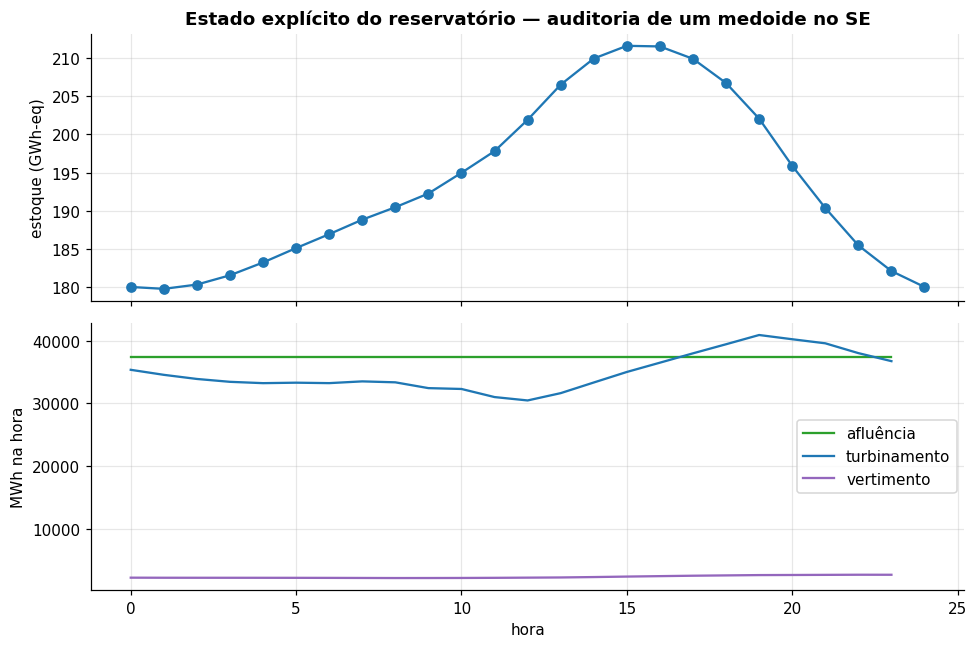

In [36]:
reservoir_audit = clear_bench["diagnostics"][[
    "block", "loc", "storage_initial_MWh", "storage_final_MWh",
    "hydro_MWh_day", "spill_MWh_day", "reservoir_balance_max_abs",
]].copy()
reservoir_audit["cyclic_gap_MWh"] = (
    reservoir_audit["storage_final_MWh"] - reservoir_audit["storage_initial_MWh"])
reservoir_audit.to_csv(TABLE_DIR / "reservoir_audit.csv", index=False)
assert reservoir_audit["reservoir_balance_max_abs"].max() < 1e-2
assert reservoir_audit["cyclic_gap_MWh"].abs().max() < 1e-2
display(reservoir_audit.round(4))

sample = reservoir_path[(reservoir_path["loc"] == "SE") &
                        (reservoir_path["block"] == reservoir_path["block"].iloc[0])]
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(sample["hour"], sample["storage_MWh"] / 1000, marker="o", color="#1f77b4")
axes[0].set_ylabel("estoque (GWh-eq)")
axes[0].set_title("Estado explícito do reservatório — auditoria de um medoide no SE")
axes[0].grid(alpha=0.3)
axes[1].plot(sample["hour"], sample["inflow_MWh"], label="afluência", color="#2ca02c")
axes[1].plot(sample["hour"], sample["hydro_MWh"], label="turbinamento", color="#1f77b4")
axes[1].plot(sample["hour"], sample["spill_MWh"], label="vertimento", color="#9467bd")
axes[1].set_xlabel("hora"); axes[1].set_ylabel("MWh na hora")
axes[1].grid(alpha=0.3); axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "reservoir_state_audit.png", bbox_inches="tight")
plt.show()


### 4.4 Energia agregada não implica adequação horária

Uma soma diária pode sugerir energia suficiente e, ainda assim, esconder déficit.
Mesmo que

$$\sum_t\left(\bar g^s_t+\bar g^w_t+\bar n_t+A_t\right)
\geq\sum_t L_t,$$

não segue que, para toda hora,

$$\bar g^s_t+\bar g^w_t+\bar n_t+\bar h_t+F^{net,max}_t\geq L_t.$$

A primeira desigualdade é apenas uma condição agregada de **energia**. A segunda é
uma condição horária de **potência, localização e flexibilidade**; mesmo ela é
somente necessária se rampas, estoque e congestionamento acoplarem as horas. Essa
distinção explica por que solar abundante ao meio-dia não elimina, por si só, a
escassez no começo da noite.

### 4.5 Sensibilidade hidrológica: seco, base e úmido

Mantemos capacidade, custos, rede e demanda fixos e multiplicamos a afluência
equivalente por $0{,}70$, $1{,}00$ e $1{,}30$. Portanto, qualquer diferença entre
os cenários vem apenas do estado hidrológico no mesmo operador de clearing. A
comparação mede como escassez de água altera preço-sombra, térmica, déficit,
vertimento e corte solar; não é uma previsão probabilística de afluências.

### 4.5.1 Termos quadráticos, sensibilidade a $\gamma_r$ e auditoria do vertimento

Para um bloco térmico interior, a condição de primeira ordem inclui
$\varepsilon_n n_{b,t}$ e o termo de suavização
$2\gamma_r(2n_t-n_{t-1}-n_{t+1})$ (com versões unilaterais nas pontas).
O primeiro dá inclinação ao custo marginal; o segundo troca custo instantâneo por
um despacho térmico mais suave. A célula seguinte zera cada regularizador e varia
$\gamma_r$ mantendo todo o restante fixo, reportando preço, energia e rampa RMS.
Na execução, os termos quadráticos quase não alteram a energia térmica anual nem o
vertimento, mas alteram bastante a alocação horária: sem $\gamma_r$, a rampa RMS
sobe de 40,44 para 90,43 MW. A sensibilidade a $\gamma_r$ é, portanto, grande para
suavização temporal e quase nula para preço médio e totais anuais. Tikhonov também
muda qual despacho é selecionado entre soluções quase equivalentes, razão pela qual
esses termos não devem ser tratados como simples detalhes do solver.

O vertimento também é decomposto pela identidade do reservatório. Como cada medoide
fecha em $S_{24}=S_0$, vale exatamente $\sum_t A_t=\sum_t h_t+\sum_t v_t$.
Logo, a auditoria distingue erro numérico de hipótese: afluência construída a partir
da hidro observada, custo de oportunidade positivo e ausência de transferência de
água entre medoides podem tornar o vertimento alto mesmo com a equação correta.


,scenario,inflow_scale,lambda_mean_RS_MWh,thermal_TWh_annualized,hydro_TWh_annualized,spill_TWh_annualized,solar_curt_TWh_annualized,wind_curt_TWh_annualized,deficit_TWh_annualized,reservoir_balance_max_abs_MWh,cyclic_gap_max_abs_MWh
0,Seco (-30%),0.7,7474.2608,141.5587,276.0214,0.8923,0.0,0.0,52.9253,0.0,0.0
1,Base,1.0,277.0407,97.5433,372.9621,22.6289,0.0,0.0,0.0000,0.0,0.0
2,Úmido (+30%),1.3,254.5063,93.9356,376.5699,137.6986,0.0,0.0,0.0000,0.0,0.0


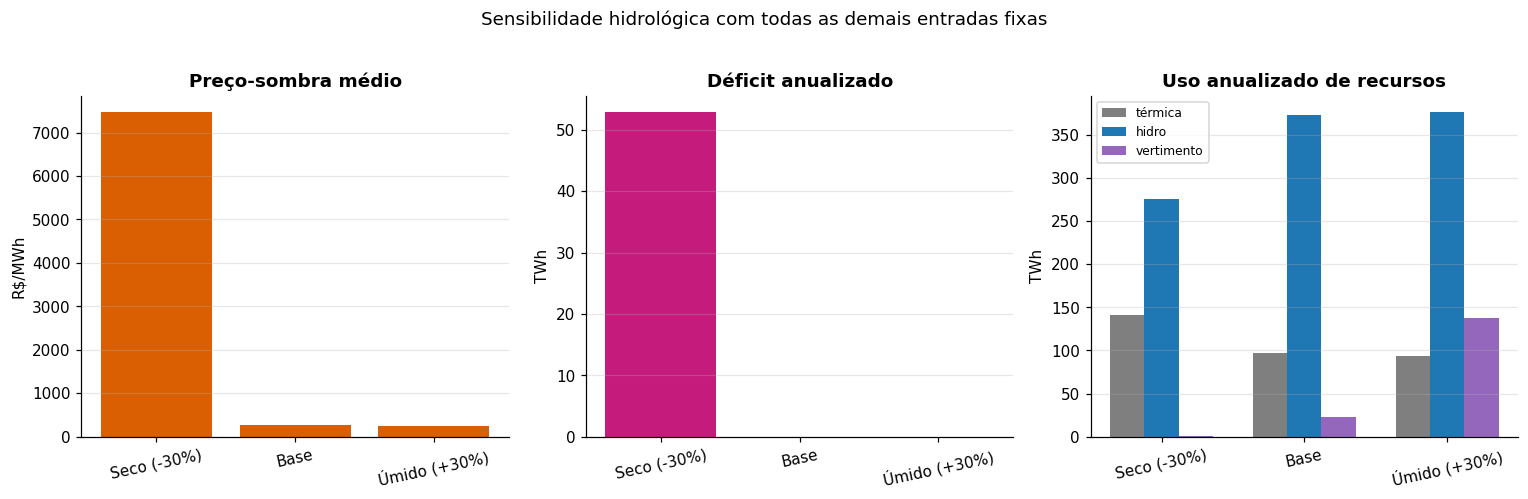

termos quadráticos: 100%|██████████| 5/5 [00:03<00:00,  1.56it/s]


,scenario,epsilon_n,gamma_r,epsilon_x,lambda_mean_RS_MWh,thermal_TWh_annualized,spill_TWh_annualized,deficit_TWh_annualized,thermal_ramp_rms_MW
0,baseline,0.0002,0.002,0.01,277.0407,97.5433,22.6289,0.0,40.4355
1,sem epsilon_n,0.0000,0.002,0.01,276.9659,97.5433,22.6289,0.0,47.4849
2,sem gamma_r,0.0002,0.000,0.01,277.0312,97.5433,22.6289,0.0,90.4295
3,sem Tikhonov,0.0002,0.002,0.00,272.9504,97.5433,22.6289,0.0,0.0001
4,sem quadráticos,0.0000,0.000,0.00,272.9080,97.5433,22.6289,0.0,7.7730


,gamma_r,lambda_mean_RS_MWh,thermal_TWh_annualized,spill_TWh_annualized,deficit_TWh_annualized,thermal_ramp_rms_MW
0,0.0000,277.03118,97.54332,22.62895,0.0,90.42948
1,0.0005,277.03020,97.54332,22.62895,0.0,60.09135
2,0.0010,277.03450,97.54332,22.62895,0.0,49.68933
3,0.0020,277.04065,97.54332,22.62895,0.0,40.43546
4,0.0050,277.04157,97.54332,22.62895,0.0,27.44525
5,0.0100,277.04157,97.54332,22.62895,0.0,19.21405


,loc,inflow_weighted,hydro_weighted,spill_weighted,spill_share_inflow
0,N,6.460461e+07,4.904702e+07,1.555758e+07,0.2408
1,NE,2.605324e+07,2.605324e+07,6.880000e-02,0.0000
2,S,7.339265e+07,7.339265e+07,8.670000e-02,0.0000
3,SE,2.315406e+08,2.244692e+08,7.071366e+06,0.0305


In [37]:
HYDROLOGY_SCENARIOS = [
    ("Seco (-30%)", 0.70),
    ("Base", 1.00),
    ("Úmido (+30%)", 1.30),
]

hydrology_rows = []
for scenario, inflow_scale in HYDROLOGY_SCENARIOS:
    scenario_engine = DispatchEngineCVX(
        load, cf_solar, wind_avail, nuc_avail, hydro_inflow * inflow_scale,
        reservoir_capacity, weights, PARAMS)
    scenario_clear = scenario_engine.solve(obs_K_by_type())
    dg = scenario_clear["diagnostics"].copy()
    annual = lambda column: float((dg[column] * dg["weight_days"]).sum())
    lambda_weighted = float(np.average(dg["lambda_mean"], weights=dg["weight_days"]))
    hydrology_rows.append({
        "scenario": scenario,
        "inflow_scale": inflow_scale,
        "lambda_mean_RS_MWh": lambda_weighted,
        "thermal_TWh_annualized": annual("thermal_MWh_day") / 1e6,
        "hydro_TWh_annualized": annual("hydro_MWh_day") / 1e6,
        "spill_TWh_annualized": annual("spill_MWh_day") / 1e6,
        "solar_curt_TWh_annualized": annual("solar_curt_MWh_day") / 1e6,
        "wind_curt_TWh_annualized": annual("wind_curt_MWh_day") / 1e6,
        "deficit_TWh_annualized": annual("deficit_MWh_day") / 1e6,
        "reservoir_balance_max_abs_MWh": float(
            dg["reservoir_balance_max_abs"].max()),
        "cyclic_gap_max_abs_MWh": float(
            (dg["storage_final_MWh"] - dg["storage_initial_MWh"]).abs().max()),
    })

hydrology_sensitivity = pd.DataFrame(hydrology_rows)
hydrology_sensitivity.to_csv(TABLE_DIR / "hydrology_sensitivity.csv", index=False)
assert hydrology_sensitivity["reservoir_balance_max_abs_MWh"].max() < 1e-2
assert hydrology_sensitivity["cyclic_gap_max_abs_MWh"].max() < 1e-2
display(hydrology_sensitivity.round(4))

labels = hydrology_sensitivity["scenario"].tolist()
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].bar(x, hydrology_sensitivity["lambda_mean_RS_MWh"], color="#d95f02")
axes[0].set_title("Preço-sombra médio")
axes[0].set_ylabel("R$/MWh")
axes[1].bar(x, hydrology_sensitivity["deficit_TWh_annualized"], color="#c51b7d")
axes[1].set_title("Déficit anualizado")
axes[1].set_ylabel("TWh")
width = 0.24
for shift, column, label, color in [
    (-width, "thermal_TWh_annualized", "térmica", "#7f7f7f"),
    (0.0, "hydro_TWh_annualized", "hidro", "#1f77b4"),
    (width, "spill_TWh_annualized", "vertimento", "#9467bd"),
]:
    axes[2].bar(x + shift, hydrology_sensitivity[column], width,
                label=label, color=color)
axes[2].set_title("Uso anualizado de recursos")
axes[2].set_ylabel("TWh")
axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=12)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Sensibilidade hidrológica com todas as demais entradas fixas", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "hydrology_sensitivity.png", bbox_inches="tight")
plt.show()

# Impacto dos termos quadráticos no despacho, um mecanismo por vez.
QUADRATIC_SCENARIOS = [
    ("baseline", {}),
    ("sem epsilon_n", {"thermal_quad": 0.0}),
    ("sem gamma_r", {"thermal_ramp_penalty": 0.0}),
    ("sem Tikhonov", {"clearing_tikhonov": 0.0}),
    ("sem quadráticos", {"thermal_quad": 0.0, "thermal_ramp_penalty": 0.0,
                          "clearing_tikhonov": 0.0}),
]
quadratic_rows = []
quadratic_clearings = {}
for scenario, overrides in tqdm(QUADRATIC_SCENARIOS, desc="termos quadráticos"):
    p_test = {**PARAMS, **overrides}
    cl_test = DispatchEngineCVX(load, cf_solar, wind_avail, nuc_avail, hydro_inflow,
                                reservoir_capacity, weights, p_test).solve(obs_K_by_type())
    quadratic_clearings[scenario] = cl_test
    dg = cl_test["diagnostics"]
    thermal_total = cl_test["g_th"].sum(axis=2)
    ramp = np.diff(thermal_total, axis=2)
    quadratic_rows.append({
        "scenario": scenario,
        "epsilon_n": p_test["thermal_quad"],
        "gamma_r": p_test["thermal_ramp_penalty"],
        "epsilon_x": p_test["clearing_tikhonov"],
        "lambda_mean_RS_MWh": float(np.average(dg["lambda_mean"], weights=dg["weight_days"])),
        "thermal_TWh_annualized": float((dg["thermal_MWh_day"] * dg["weight_days"]).sum() / 1e6),
        "spill_TWh_annualized": float((dg["spill_MWh_day"] * dg["weight_days"]).sum() / 1e6),
        "deficit_TWh_annualized": float((dg["deficit_MWh_day"] * dg["weight_days"]).sum() / 1e6),
        "thermal_ramp_rms_MW": float(np.sqrt(
            np.sum(weights[:, None, None] * ramp ** 2)
            / (weights.sum() * ramp.shape[1] * ramp.shape[2]))),
    })
quadratic_sensitivity = pd.DataFrame(quadratic_rows)
quadratic_sensitivity.to_csv(TABLE_DIR / "dispatch_quadratic_terms_sensitivity.csv", index=False)
display(quadratic_sensitivity.round(4))

# Sensibilidade específica ao gamma_r pedida na revisão.
gamma_r_rows = []
for gamma_r in [0.0, 5e-4, 1e-3, PARAMS["thermal_ramp_penalty"], 5e-3, 1e-2]:
    p_gamma = {**PARAMS, "thermal_ramp_penalty": float(gamma_r)}
    cl_gamma = DispatchEngineCVX(load, cf_solar, wind_avail, nuc_avail, hydro_inflow,
                                 reservoir_capacity, weights, p_gamma).solve(obs_K_by_type())
    dg = cl_gamma["diagnostics"]
    ramp = np.diff(cl_gamma["g_th"].sum(axis=2), axis=2)
    gamma_r_rows.append({
        "gamma_r": gamma_r,
        "lambda_mean_RS_MWh": float(np.average(dg["lambda_mean"], weights=dg["weight_days"])),
        "thermal_TWh_annualized": float((dg["thermal_MWh_day"] * dg["weight_days"]).sum() / 1e6),
        "spill_TWh_annualized": float((dg["spill_MWh_day"] * dg["weight_days"]).sum() / 1e6),
        "deficit_TWh_annualized": float((dg["deficit_MWh_day"] * dg["weight_days"]).sum() / 1e6),
        "thermal_ramp_rms_MW": float(np.sqrt(
            np.sum(weights[:, None, None] * ramp ** 2)
            / (weights.sum() * ramp.shape[1] * ramp.shape[2]))),
    })
gamma_r_sensitivity = pd.DataFrame(gamma_r_rows)
gamma_r_sensitivity.to_csv(TABLE_DIR / "gamma_r_sensitivity.csv", index=False)
display(gamma_r_sensitivity.round(5))

# Auditoria causal do vertimento no baseline.
spill_dg = clear_bench["diagnostics"].copy()
spill_dg["inflow_MWh_day"] = spill_dg["hydro_MWh_day"] + spill_dg["spill_MWh_day"]
spill_dg["spill_share_inflow"] = np.divide(spill_dg["spill_MWh_day"],
                                           spill_dg["inflow_MWh_day"],
                                           out=np.zeros(len(spill_dg)),
                                           where=spill_dg["inflow_MWh_day"] > 1e-9)
spill_by_loc = (spill_dg.assign(
    inflow_weighted=lambda d: d["inflow_MWh_day"] * d["weight_days"],
    hydro_weighted=lambda d: d["hydro_MWh_day"] * d["weight_days"],
    spill_weighted=lambda d: d["spill_MWh_day"] * d["weight_days"])
    .groupby("loc", as_index=False)[["inflow_weighted", "hydro_weighted", "spill_weighted"]].sum())
spill_by_loc["spill_share_inflow"] = spill_by_loc["spill_weighted"] / spill_by_loc["inflow_weighted"]
spill_by_loc.to_csv(TABLE_DIR / "spill_diagnostic_by_region.csv", index=False)
display(spill_by_loc.round(4))


### 4.6 Realimentação de campo médio: de $\Lambda'$ à canibalização $R_\ell(C)$

A notação $\lambda_t=\Lambda(x_t)$ separa o valor horário $\lambda_t$ do mapa
$\Lambda$ que leva carga residual $x_t=L_t-G_t^w-G_t^s$ ao preço. Não escolhemos
uma função polinomial externa. No código, `DispatchEngineCVX.solve` resolve o QP e
extrai o dual do balanço; portanto $\Lambda$ é o mapa implícito
$x\mapsto \partial V^*(x)/\partial L$. Como $V^*$ é convexo, sua inclinação local
$\Lambda'$ é não negativa dentro de cada regime ativo e pode mudar em quinas quando
um bloco térmico ou uma interface entra/sai do limite. A célula abaixo estima uma
derivada direcional média por diferença finita de +100 MW de carga em cada região;
ela é um diagnóstico do clearing, não uma regressão imposta aos dados do ONS.

A receita anual por MW de um projeto solar em $\ell$ é o preço capturado vezes o
perfil: $R_\ell(m)=\sum_t \lambda_{\ell,t}\,a_{\ell,t}$. Como $\lambda$ sai do
clearing, $R_\ell$ **depende de $m$** (via $C_\ell$). O teste abaixo varre uma
escala comum de capacidade e mostra a propriedade decisiva: **$R_\ell$ cai com a
capacidade** (mais solar ⇒ preço de meio-dia desaba). Essa realimentação
negativa (substitutos estratégicos) favorece estabilidade, mas **não prova** que o
operador de melhor resposta seja uma contração. Por isso reportamos o resíduo do
ponto fixo e não inferimos convergência apenas pelo formato desta curva.


canibalização R(C): 100%|██████████| 6/6 [00:00<00:00, 10.92it/s]


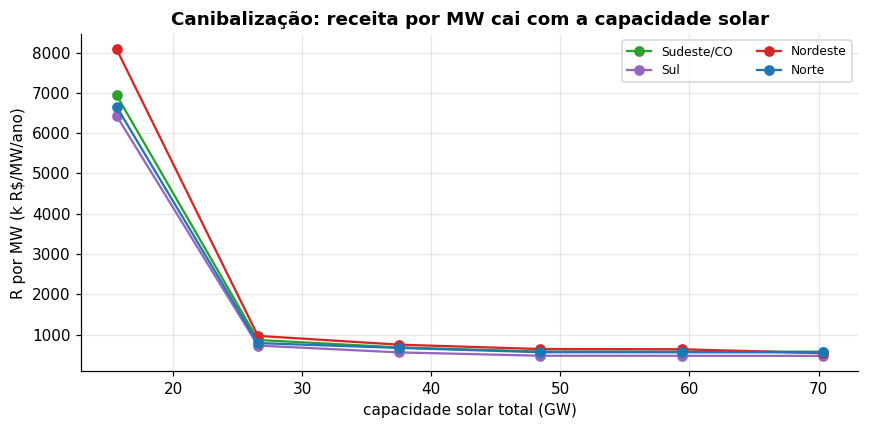

 K_total_GW      SE       S      NE       N
      15.63 6934.54 6423.49 8076.81 6649.94
      26.57  864.95  725.84  966.57  787.68
      37.51  678.75  556.38  747.77  667.09
      48.45  577.41  472.93  639.66  561.36
      59.39  574.99  471.26  634.38  559.81
      70.32  572.74  469.66  535.70  558.25


,loc,delta_load_MW,lambda_base_RS_MWh,lambda_perturbed_RS_MWh,lambda_prime_RS_MWh_per_MW
0,SE,100.0,277.600579,277.629218,0.000286
1,S,100.0,277.938787,296.698045,0.187593
2,NE,100.0,277.594976,277.624317,0.000293
3,N,100.0,275.028276,275.057619,0.000293


,delta_load_MW,south_secant_RS_MWh_per_MW,D02_lambda_change_RS_MWh,D02_SE_S_saturated_hours_baseline,D02_SE_S_saturated_hours_perturbed,D02_additional_medium_high_thermal_MWh_day
0,1.0,0.001127,0.003572,21,21,0.000000
1,5.0,0.001127,0.017876,21,21,0.000013
2,10.0,0.001160,0.037164,21,21,0.000019
3,25.0,0.001380,0.117820,21,22,0.000049
4,50.0,0.001451,0.254730,21,22,0.000140
5,60.0,0.001463,0.309653,21,22,0.000174
6,65.0,0.287139,81.022018,21,24,7.421454
7,70.0,0.267185,81.185480,21,24,127.422269
8,75.0,0.249552,81.238485,21,24,247.422507
9,80.0,0.234095,81.281495,21,24,367.421825


In [38]:
mult_grid = np.linspace(0.4, 1.8, 6)
canib = []
for mlt in tqdm(mult_grid, desc="canibalização R(C)"):
    Kbt = {s: {th: K_SOLAR_OBS[s] * TYPE_WEIGHT[th] * mlt for th in AGENT_TYPES} for s in LOCS}
    cl = engine.solve(Kbt)
    Ktot = sum(Kbt[s][th] for s in LOCS for th in AGENT_TYPES)
    row = {"K_total_GW": Ktot / 1000}
    for s in LOCS:
        row[s] = 0.5 * (cl["R"][(s, "high")] / TYPE_PROD["high"] + cl["R"][(s, "low")] / TYPE_PROD["low"]) / 1e3
    canib.append(row)
canib = pd.DataFrame(canib)

fig, ax = plt.subplots(figsize=(8, 4))
for s in LOCS:
    ax.plot(canib["K_total_GW"], canib[s], marker="o", label=SUB_LABEL[s], color=SUB_COLOR[s])
ax.set_title("Canibalização: receita por MW cai com a capacidade solar")
ax.set_xlabel("capacidade solar total (GW)"); ax.set_ylabel("R por MW (k R$/MW/ano)")
ax.grid(alpha=0.3); ax.legend(ncol=2, fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "canibalizacao_R_de_C.png", bbox_inches="tight"); plt.show()
print(canib.round(2).to_string(index=False))

# Lambda' médio do clearing: perturbação locacional de +100 MW em todas as horas.
lambda_prime_rows = []
delta_load_MW = 100.0
base_diag = clear_bench["diagnostics"]
for li, loc in enumerate(LOCS):
    perturbed_load = load.copy()
    perturbed_load[:, li, :] += delta_load_MW
    cl_pert = DispatchEngineCVX(perturbed_load, cf_solar, wind_avail, nuc_avail,
                                hydro_inflow, reservoir_capacity, weights,
                                PARAMS).solve(obs_K_by_type())
    pert_diag = cl_pert["diagnostics"]
    base_loc = base_diag[base_diag["loc"] == loc]
    pert_loc = pert_diag[pert_diag["loc"] == loc]
    lam0 = float(np.average(base_loc["lambda_mean"], weights=base_loc["weight_days"]))
    lam1 = float(np.average(pert_loc["lambda_mean"], weights=pert_loc["weight_days"]))
    lambda_prime_rows.append({"loc": loc, "delta_load_MW": delta_load_MW,
                              "lambda_base_RS_MWh": lam0,
                              "lambda_perturbed_RS_MWh": lam1,
                              "lambda_prime_RS_MWh_per_MW": (lam1 - lam0) / delta_load_MW})
lambda_prime_sensitivity = pd.DataFrame(lambda_prime_rows)
lambda_prime_sensitivity.to_csv(TABLE_DIR / "lambda_prime_sensitivity.csv", index=False)
display(lambda_prime_sensitivity.round(6))

# Auditoria do tamanho do passo no Sul: identifica a quina de rede/mérito térmico.
south_i = LOCS.index("S")
se_s_edge = EDGES.index(("SE", "S"))
d02_i = int(rep_days.index[rep_days["block"].eq("D02")][0])
base_south_lambda = float(np.average(
    clear_bench["lambda"][:, south_i, :].mean(axis=1), weights=weights))
base_d02_lambda = float(clear_bench["lambda"][d02_i, south_i, :].mean())
base_d02_saturated_hours = int(np.sum(
    np.abs(clear_bench["flow"][d02_i, se_s_edge, :]) >= FMAX[se_s_edge] - 1.0))
base_d02_medium_high = float(clear_bench["g_th"][d02_i, south_i, 1:, :].sum())
south_lambda_step_rows = []
for delta_MW in [1.0, 5.0, 10.0, 25.0, 50.0, 60.0, 65.0, 70.0, 75.0, 80.0, 90.0, 100.0]:
    load_step = load.copy()
    load_step[:, south_i, :] += delta_MW
    cl_step = DispatchEngineCVX(load_step, cf_solar, wind_avail, nuc_avail,
                                hydro_inflow, reservoir_capacity, weights,
                                PARAMS).solve(obs_K_by_type())
    step_south_lambda = float(np.average(
        cl_step["lambda"][:, south_i, :].mean(axis=1), weights=weights))
    south_lambda_step_rows.append({
        "delta_load_MW": delta_MW,
        "south_secant_RS_MWh_per_MW": (step_south_lambda - base_south_lambda) / delta_MW,
        "D02_lambda_change_RS_MWh": float(
            cl_step["lambda"][d02_i, south_i, :].mean() - base_d02_lambda),
        "D02_SE_S_saturated_hours_baseline": base_d02_saturated_hours,
        "D02_SE_S_saturated_hours_perturbed": int(np.sum(
            np.abs(cl_step["flow"][d02_i, se_s_edge, :]) >= FMAX[se_s_edge] - 1.0)),
        "D02_additional_medium_high_thermal_MWh_day": float(
            cl_step["g_th"][d02_i, south_i, 1:, :].sum() - base_d02_medium_high),
    })
south_lambda_step_sensitivity = pd.DataFrame(south_lambda_step_rows)
south_lambda_step_sensitivity.to_csv(
    TABLE_DIR / "lambda_prime_south_step_sensitivity.csv", index=False)
display(south_lambda_step_sensitivity.round(6))

### Leitura da sensibilidade no Sul

O valor de $\widehat\Lambda'_S$ para 100 MW é uma secante que atravessa uma mudança
de regime, não uma derivada infinitesimal. D02, com peso de 84 dias, passa de 21
para 24 horas com a interface SE--S saturada e aciona o bloco térmico seguinte.
Por isso ele domina a média anual. A tabela
`lambda_prime_south_step_sensitivity.csv` mostra que passos de 1 a 10 MW ficam
perto de 0,0011 R$/MWh por MW e que a quina aparece entre 60 e 65 MW. A seção
“Receita capturada e canibalização” do `report_v2.typ` usa exatamente essa auditoria.


## 5. Laboratório situacional finito — incumbente e entrante solar

Antes de passar ao campo médio, isolamos o mecanismo com dois produtores solares.
O produtor 1 é o incumbente e o produtor 2 entra com
$K_2=\kappa K_1$. Ambos enfrentam o mesmo clearing com térmica, hidro,
reservatório, rede, eólica e nuclear. Para cada produtor distinguimos:

$$Rev_i=\sum_{d,t}p_d\lambda_{d,\ell,t}g_{i,d,t},\qquad
R_i^{cap}=\frac{Rev_i}{\sum_{d,t}p_d g_{i,d,t}}.$$

Quando há curtailment agregado, a energia entregue é rateada proporcionalmente ao
potencial horário dos dois projetos. Este não é ainda um MFG: é uma ponte finita e
transparente entre canibalização, entrada e a realimentação agregada do modelo.


,kappa,K1_MW,K2_MW,revenue_1_RS,revenue_2_RS,captured_1_RS_MWh,captured_2_RS_MWh,curtailment_1_MWh,curtailment_2_MWh,profit_1_RS,profit_2_RS,lambda_mean_RS_MWh,deficit_MWh
0,0.00,11446.23,0.00,8.950860e+09,0.000000e+00,319.09,NaN,0.00,0.00,4.151808e+09,0.000000e+00,314.69,0.0
1,0.25,11446.23,2861.56,8.434427e+09,1.835269e+09,300.68,300.68,0.00,0.00,3.635375e+09,4.568177e+08,294.00,0.0
2,0.50,11446.23,5723.11,8.390121e+09,3.651256e+09,299.10,299.10,0.00,0.00,3.591068e+09,8.943538e+08,292.62,0.0
3,0.75,11446.23,8584.67,7.842777e+09,5.119591e+09,279.58,279.58,0.00,0.00,3.043725e+09,9.842369e+08,274.82,0.0
4,1.00,11446.23,11446.23,7.794586e+09,6.784176e+09,277.87,277.87,0.01,0.01,2.995533e+09,1.270371e+09,273.56,0.0
5,1.25,11446.23,14307.79,7.143626e+09,7.772000e+09,254.66,254.66,0.01,0.01,2.344573e+09,8.797443e+08,255.91,0.0
6,1.50,11446.23,17169.34,7.135542e+09,9.315847e+09,254.37,254.37,0.00,0.00,2.336490e+09,1.045140e+09,255.75,0.0


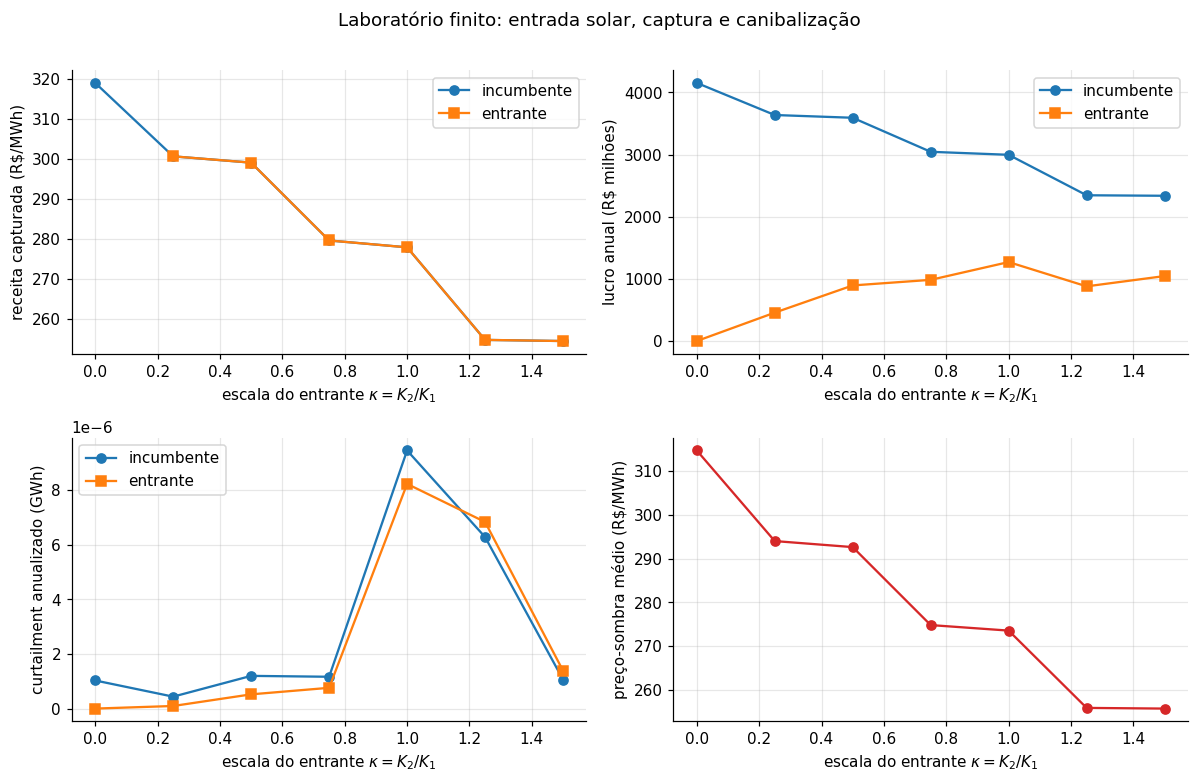

In [39]:
SIT_LOC = "SE"
sit_i = LOCS.index(SIT_LOC)
SIT_K1_MW = 0.60 * K_SOLAR_OBS[SIT_LOC]
sit_rows = []
for kappa in np.linspace(0.0, 1.5, 7):
    K1 = SIT_K1_MW
    K2 = float(kappa * K1)
    Kbt = obs_K_by_type()
    Kbt[SIT_LOC] = {"high": K1, "low": K2}
    clearing = engine.solve(Kbt)
    potential_1 = K1 * TYPE_PROD["high"] * cf_solar[:, sit_i, :]
    potential_2 = K2 * TYPE_PROD["low"] * cf_solar[:, sit_i, :]
    aggregate_potential = potential_1 + potential_2
    delivered_fraction = np.divide(
        clearing["g_solar"][:, sit_i, :], aggregate_potential,
        out=np.zeros_like(aggregate_potential), where=aggregate_potential > 1e-9)
    delivered_fraction = np.clip(delivered_fraction, 0.0, 1.0)
    generation_1 = potential_1 * delivered_fraction
    generation_2 = potential_2 * delivered_fraction
    lam = clearing["lambda"][:, sit_i, :]

    def annual_sum(x):
        return float(np.sum(weights[:, None] * x))

    energy_1 = annual_sum(generation_1)
    energy_2 = annual_sum(generation_2)
    revenue_1 = annual_sum(lam * generation_1)
    revenue_2 = annual_sum(lam * generation_2)
    sit_rows.append({
        "kappa": kappa, "K1_MW": K1, "K2_MW": K2,
        "revenue_1_RS": revenue_1, "revenue_2_RS": revenue_2,
        "captured_1_RS_MWh": revenue_1 / energy_1 if energy_1 > 0 else np.nan,
        "captured_2_RS_MWh": revenue_2 / energy_2 if energy_2 > 0 else np.nan,
        "curtailment_1_MWh": annual_sum(potential_1 - generation_1),
        "curtailment_2_MWh": annual_sum(potential_2 - generation_2),
        "profit_1_RS": revenue_1 - q_type[(SIT_LOC, "high")] * K1,
        "profit_2_RS": revenue_2 - q_type[(SIT_LOC, "low")] * K2,
        "lambda_mean_RS_MWh": float(np.mean(lam)),
        "deficit_MWh": annual_sum(clearing["deficit"][:, sit_i, :]),
    })
finite_two_player = pd.DataFrame(sit_rows)
finite_two_player.to_csv(TABLE_DIR / "finite_two_player_sensitivity.csv", index=False)
display(finite_two_player.round(2))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(finite_two_player["kappa"], finite_two_player["captured_1_RS_MWh"],
                marker="o", label="incumbente")
axes[0, 0].plot(finite_two_player["kappa"], finite_two_player["captured_2_RS_MWh"],
                marker="s", label="entrante")
axes[0, 0].set_ylabel("receita capturada (R$/MWh)"); axes[0, 0].legend()
axes[0, 1].plot(finite_two_player["kappa"], finite_two_player["profit_1_RS"] / 1e6,
                marker="o", label="incumbente")
axes[0, 1].plot(finite_two_player["kappa"], finite_two_player["profit_2_RS"] / 1e6,
                marker="s", label="entrante")
axes[0, 1].set_ylabel("lucro anual (R$ milhões)"); axes[0, 1].legend()
axes[1, 0].plot(finite_two_player["kappa"], finite_two_player["curtailment_1_MWh"] / 1e3,
                marker="o", label="incumbente")
axes[1, 0].plot(finite_two_player["kappa"], finite_two_player["curtailment_2_MWh"] / 1e3,
                marker="s", label="entrante")
axes[1, 0].set_ylabel("curtailment anualizado (GWh)"); axes[1, 0].legend()
axes[1, 1].plot(finite_two_player["kappa"], finite_two_player["lambda_mean_RS_MWh"],
                marker="o", color="#d62728")
axes[1, 1].set_ylabel("preço-sombra médio (R$/MWh)")
for ax in axes.ravel():
    ax.set_xlabel(r"escala do entrante $\kappa=K_2/K_1$")
    ax.grid(alpha=0.3)
fig.suptitle("Laboratório finito: entrada solar, captura e canibalização", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "finite_two_player_sensitivity.png", bbox_inches="tight")
plt.show()


## 6. Benchmark estático de campo médio

O benchmark reduzido mantém a massa regional fixa e resolve uma escolha
**contínua** de capacidade. Ele é útil para calibração, sensibilidade e comparação
com o planejador, mas não substitui o MFG dinâmico da Seção 10.

### 6.1 Melhor resposta contínua

Para um tipo $\theta$ em $\ell$:

$$U_{\ell,\theta}(k)=
(R_{\ell,\theta}-q_{\ell,\theta})\kappa_u k-\frac{\gamma}{2}k^2.$$

O ótimo contínuo é projetado nos dois nós adjacentes da grade por coordenadas
baricêntricas. A projeção preserva exatamente seu momento de capacidade, mas não é
chamada de mistura ótima de um jogo discreto: dois bins só podem sustentar uma
mistura discreta exata quando são indiferentes.


In [40]:
p_loc = {s: K_SOLAR_OBS[s] / max(K_SOLAR_TOTAL_OBS, 1e-9) for s in LOCS}
p_state = {(s, agent_type): p_loc[s] * TYPE_WEIGHT[agent_type]
           for s in LOCS for agent_type in AGENT_TYPES}


def initial_m() -> np.ndarray:
    m = np.zeros((N_LOC, len(AGENT_TYPES), N_K), float)
    for i, s in enumerate(LOCS):
        for j, agent_type in enumerate(AGENT_TYPES):
            m[i, j, K0_BIN] = p_state[(s, agent_type)]
    return m / m.sum()


def capacity_by_type_from_m(m: np.ndarray) -> dict[str, dict[str, float]]:
    out = {s: {} for s in LOCS}
    for i, s in enumerate(LOCS):
        for j, agent_type in enumerate(AGENT_TYPES):
            out[s][agent_type] = float(np.sum(m[i, j, :] * K_BINS) * CAP_UNIT_MW)
    return out


def total_capacity_from_m(m: np.ndarray) -> float:
    capacity = capacity_by_type_from_m(m)
    return float(sum(capacity[s][agent_type]
                     for s in LOCS for agent_type in AGENT_TYPES))


def best_response(R, gamma_bin, premium_RS_MW_ano=0.0, q_table=None) -> np.ndarray:
    """Representação baricêntrica da melhor resposta contínua na grade numérica."""
    q_table = q_table or q_type
    m_star = np.zeros((N_LOC, len(AGENT_TYPES), N_K), float)
    for i, s in enumerate(LOCS):
        for j, agent_type in enumerate(AGENT_TYPES):
            margin = R[(s, agent_type)] + premium_RS_MW_ano - q_table[(s, agent_type)]
            if TAU > 0:
                utility = (margin * CAP_UNIT_MW * K_BINS
                           - 0.5 * gamma_bin * K_BINS ** 2)
                weight = np.exp(np.clip((utility - utility.max()) / TAU, -80, 80))
            else:
                k_star = 0.0 if gamma_bin <= 0 else margin * CAP_UNIT_MW / gamma_bin
                k_star = float(np.clip(k_star, 0.0, N_K - 1))
                lower = int(np.floor(k_star))
                upper = min(lower + 1, N_K - 1)
                fraction = k_star - lower
                weight = np.zeros(N_K, float)
                weight[lower] += 1.0 - fraction
                weight[upper] += fraction
            m_star[i, j, :] = p_state[(s, agent_type)] * weight / max(weight.sum(), 1e-300)
    return m_star / m_star.sum()


### 6.2 Ponto fixo e certificado do benchmark estático

O objeto é $m=BR(R(m))$. A relaxação

$$m^{n+1}=(1-\alpha)m^n+\alpha BR(R(m^n))$$

é apenas um método numérico. Por isso, **não** usamos
$\lVert m^{n+1}-m^n\rVert$ como certificado: esse passo pode ser pequeno apenas
porque $\alpha$ é pequeno. O teste válido é feito antes da relaxação:

$$r_m=\lVert BR(R(m))-m\rVert_\infty,\qquad
r_C=\max_\ell\frac{|C_\ell(BR)-C_\ell(m)|}{C_\ell(m)+1}.$$

Ao final também recalculamos o clearing na melhor resposta e reportamos
$r_R$, o resíduo relativo das receitas/preços. O benchmark só recebe o rótulo
`certificado=True` quando os três resíduos satisfazem suas tolerâncias.


In [41]:
def _cap_by_loc(m: np.ndarray) -> np.ndarray:
    capacity = capacity_by_type_from_m(m)
    return np.array([
        sum(capacity[s][agent_type] for agent_type in AGENT_TYPES) for s in LOCS
    ], float)


def solve_mfg(gamma_bin=GAMMA_BIN_DEFAULT, premium_RS_MW_ano=0.0, q_table=None,
              max_iter=MAX_ITER, registrar=True, progress=True, desc=None):
    q_table = q_table or q_type
    m = initial_m()
    history = []
    R_previous = None
    step_C = np.inf
    step_R = np.inf
    residual_C = np.inf
    residual_m = np.inf
    iterator = range(1, max_iter + 1)
    if progress:
        iterator = tqdm(iterator, desc=desc or "benchmark estático", leave=False)

    for iteration in iterator:
        clearing = engine.solve(capacity_by_type_from_m(m))
        R_current = clearing["R"]
        m_star = best_response(R_current, gamma_bin, premium_RS_MW_ano, q_table=q_table)
        C_current = _cap_by_loc(m)
        C_star = _cap_by_loc(m_star)
        residual_m = float(np.max(np.abs(m_star - m)))
        residual_C = float(np.max(np.abs(C_star - C_current) / (C_current + 1.0)))

        alpha = STATIC_RELAXATION
        m_new = (1.0 - alpha) * m + alpha * m_star
        m_new /= m_new.sum()
        C_new = _cap_by_loc(m_new)
        step_C = float(np.max(np.abs(C_new - C_current) / (C_current + 1.0)))
        step_R = np.inf if R_previous is None else max(
            abs(R_current[key] - R_previous[key]) / (abs(R_previous[key]) + 1.0)
            for key in R_current)

        if registrar:
            diag = clearing["diagnostics"]
            history.append({
                "it": iteration, "alpha": alpha,
                "K_total_GW": float(C_current.sum()) / 1000,
                "step_C": step_C, "step_R": step_R,
                "residual_C": residual_C, "residual_m": residual_m,
                # aliases explícitos para compatibilidade com leituras anteriores
                "err_C_fp": step_C, "err_R_change": step_R, "err_C_br": residual_C,
                "lambda_mean": float(diag["lambda_mean"].mean()),
                "lambda_max": float(diag["lambda_max"].max()),
                "solar_curt_MWh_weighted": float(
                    (diag["solar_curt_MWh_day"] * diag["weight_days"]).sum()),
            })
        if progress:
            iterator.set_postfix({
                "K_GW": f"{C_current.sum()/1000:.2f}",
                "res_C": f"{residual_C:.1e}", "res_m": f"{residual_m:.1e}",
            })
        R_previous = dict(R_current)
        if residual_C < TOL_C_FP and residual_m < TOL_M_FP:
            break
        m = m_new

    final_clear = engine.solve(capacity_by_type_from_m(m))
    final_R = dict(final_clear["R"])
    final_m_star = best_response(final_R, gamma_bin, premium_RS_MW_ano, q_table)
    final_C = _cap_by_loc(m)
    final_C_star = _cap_by_loc(final_m_star)
    residual_m = float(np.max(np.abs(final_m_star - m)))
    residual_C = float(np.max(np.abs(final_C_star - final_C) / (final_C + 1.0)))
    br_clear = engine.solve(capacity_by_type_from_m(final_m_star))
    residual_R = max(
        abs(br_clear["R"][key] - final_R[key]) / (abs(final_R[key]) + 1.0)
        for key in final_R)
    certified = bool(
        residual_C < TOL_C_FP and residual_m < TOL_M_FP and residual_R < TOL_R_FP)
    return {
        "m": m, "R": final_R, "K_by_type": capacity_by_type_from_m(m),
        "K_total_MW": float(final_C.sum()), "clear": final_clear,
        "conv": certified, "certified": certified, "nit": iteration,
        "step_C": step_C, "step_R": step_R,
        "residual_C": residual_C, "residual_m": residual_m, "residual_R": residual_R,
        "err_C_fp": step_C, "err_R_change": step_R, "err_C_br": residual_C,
        "mass_border": float(m[:, :, -1].sum()), "hist": pd.DataFrame(history),
    }


### 6.3 Calibração por entrada livre

O benchmark é calibrado para reproduzir o parque solar de referência. Se o modelo
sem receita adicional escolhe capacidade excessiva, ajustamos a curvatura do custo;
se escolhe capacidade insuficiente, ajustamos um `premium` de receita não spot.
Essa calibração fixa o nível agregado e não é uma validação independente da
distribuição regional ou de previsões fora da amostra.


In [42]:
def _eval(gamma, premium):
    return solve_mfg(gamma_bin=gamma, premium_RS_MW_ano=premium,
                     max_iter=MAX_ITER_CALIB, registrar=False, progress=False)


def calibrate_gamma(target_MW, premium=0.0, lo=0.0, hi=GAMMA_BIN_DEFAULT, steps=BISECTION_STEPS):
    rows = []
    K_lo = _eval(lo, premium)["K_total_MW"]
    K_hi = _eval(hi, premium)["K_total_MW"]
    expand = 0
    while K_hi > target_MW and expand < 12:
        hi *= 1.8; K_hi = _eval(hi, premium)["K_total_MW"]; expand += 1
    best_g = lo if abs(K_lo - target_MW) <= abs(K_hi - target_MW) else hi
    best_gap = min(abs(K_lo - target_MW), abs(K_hi - target_MW))
    for it in tqdm(range(steps), desc="calibrando gamma"):
        mid = 0.5 * (lo + hi)
        K_mid = _eval(mid, premium)["K_total_MW"]
        rows.append({"it": it, "gamma_bin": mid, "gamma_MM": mid / 1e6, "K_total_GW": K_mid / 1000,
                     "target_GW": target_MW / 1000, "gap_MW": K_mid - target_MW})
        if abs(K_mid - target_MW) < best_gap:
            best_g, best_gap = mid, abs(K_mid - target_MW)
        lo, hi = (mid, hi) if K_mid > target_MW else (lo, mid)
    return best_g, pd.DataFrame(rows)


def calibrate_premium(target_MW, gamma=GAMMA_BIN_DEFAULT, lo=0.0, hi=700_000.0, steps=BISECTION_STEPS):
    rows = []
    K_lo = _eval(gamma, lo)["K_total_MW"]
    K_hi = _eval(gamma, hi)["K_total_MW"]
    expand = 0
    while K_hi < target_MW and expand < 10:
        hi *= 1.6; K_hi = _eval(gamma, hi)["K_total_MW"]; expand += 1
    best_p = lo if abs(K_lo - target_MW) <= abs(K_hi - target_MW) else hi
    best_gap = min(abs(K_lo - target_MW), abs(K_hi - target_MW))
    for it in tqdm(range(steps), desc="calibrando premium"):
        mid = 0.5 * (lo + hi)
        K_mid = _eval(gamma, mid)["K_total_MW"]
        rows.append({"it": it, "premium_RS_MW_ano": mid, "premium_k": mid / 1000,
                     "K_total_GW": K_mid / 1000, "target_GW": target_MW / 1000, "gap_MW": K_mid - target_MW})
        if abs(K_mid - target_MW) < best_gap:
            best_p, best_gap = mid, abs(K_mid - target_MW)
        lo, hi = (mid, hi) if K_mid < target_MW else (lo, mid)
    return best_p, pd.DataFrame(rows)


def calibrate_entry_wedge(target_MW):
    K0 = _eval(GAMMA_BIN_DEFAULT, 0.0)["K_total_MW"]
    print(f"Diagnóstico: γ_default={GAMMA_BIN_DEFAULT/1e6:.2f}MM, prêmio=0 -> K={K0/1000:.2f} GW; alvo={target_MW/1000:.2f} GW")
    if K0 > target_MW:
        g, path = calibrate_gamma(target_MW, premium=0.0, lo=GAMMA_BIN_DEFAULT, hi=GAMMA_BIN_DEFAULT * 2.0)
        return g, 0.0, "gamma", path
    p, path = calibrate_premium(target_MW, gamma=GAMMA_BIN_DEFAULT)
    return GAMMA_BIN_DEFAULT, p, "premium", path

### 6.4 Execução e certificado do benchmark

Depois da calibração, o benchmark é executado com horizonte numérico maior. O
resultado é classificado pelo resíduo da melhor resposta, pelo resíduo de capacidade
e pelo resíduo de preço recalculado na melhor resposta — nunca apenas pelo tamanho
do passo relaxado.


In [43]:
t0 = time.time()
GAMMA_STAR, PREMIUM_STAR, CALIBRATED_OBJECT, calibration_path = calibrate_entry_wedge(
    K_SOLAR_TOTAL_OBS)
calibration_path.to_csv(TABLE_DIR / "entry_wedge_calibration_path.csv", index=False)
print(f"Objeto calibrado: {CALIBRATED_OBJECT}")
print(f"GAMMA_STAR   = {GAMMA_STAR/1e6:.3f} MM R$/bin²")
print(f"PREMIUM_STAR = {PREMIUM_STAR/1000:.1f} k R$/MW/ano")

mfg = solve_mfg(
    gamma_bin=GAMMA_STAR, premium_RS_MW_ano=PREMIUM_STAR,
    max_iter=MAX_ITER, registrar=True, progress=True, desc="benchmark estático final")
print(
    f"\ncertificado={mfg['certified']} em {mfg['nit']} iterações | "
    f"res_C={mfg['residual_C']:.2e}, res_m={mfg['residual_m']:.2e}, "
    f"res_R={mfg['residual_R']:.2e}, massa_borda={mfg['mass_border']:.4f}")
print(f"Capacidade total: observada={K_SOLAR_TOTAL_OBS/1000:.2f} GW | "
      f"benchmark={mfg['K_total_MW']/1000:.2f} GW")
print(f"Tempo da seção: {(time.time()-t0)/60:.1f} min")
if not mfg["certified"]:
    print("AVISO: o benchmark estático é uma aproximação iterativa; os resíduos não "
          "permitem chamá-lo de ponto fixo certificado.")


Diagnóstico: γ_default=0.31MM, prêmio=0 -> K=36.72 GW; alvo=39.07 GW


calibrando premium: 100%|██████████| 9/9 [01:29<00:00,  9.90s/it]


Objeto calibrado: premium
GAMMA_STAR   = 0.312 MM R$/bin²
PREMIUM_STAR = 19.1 k R$/MW/ano



certificado=True em 132 iterações | res_C=3.37e-04, res_m=4.88e-04, res_R=4.00e-07, massa_borda=0.0000
Capacidade total: observada=39.07 GW | benchmark=38.95 GW
Tempo da seção: 2.2 min


## 7. Resultado do benchmark privado

A tabela separa, por subsistema e tipo, capacidade, receita spot por MW, custo
anualizado e margem. Como a massa regional é fixa, esta camada escolhe capacidade
dentro da região atribuída; a realocação endógena aparece somente no MFG dinâmico.
O status `certified` acompanha os números para impedir que uma aproximação iterativa
seja apresentada como ponto fixo demonstrado.


In [44]:
rows = []
for s in LOCS:
    K_loc = sum(mfg["K_by_type"][s][th] for th in AGENT_TYPES)
    for th in AGENT_TYPES:
        R0, q0 = mfg["R"][(s, th)], q_type[(s, th)]
        rows.append({"loc": s, "type": th, "K_MW": mfg["K_by_type"][s][th],
                     "K_GW": mfg["K_by_type"][s][th] / 1000, "K_loc_total_MW": K_loc,
                     "K_obs_loc_MW": K_SOLAR_OBS[s], "R_spot_RS_MW_ano": R0, "premium_RS_MW_ano": PREMIUM_STAR,
                     "q_RS_MW_ano": q0, "margin_total_RS_MW_ano": R0 + PREMIUM_STAR - q0})
eq = pd.DataFrame(rows)
eq.to_csv(TABLE_DIR / "mfg_locational_equilibrium.csv", index=False)
print(eq.round(2).to_string(index=False))

mfg["hist"].to_csv(TABLE_DIR / "mfg_convergence_history.csv", index=False)
mfg["clear"]["diagnostics"].to_csv(TABLE_DIR / "mfg_clearing_diagnostics.csv", index=False)

loc type     K_MW  K_GW  K_loc_total_MW  K_obs_loc_MW  R_spot_RS_MW_ano  premium_RS_MW_ano  q_RS_MW_ano  margin_total_RS_MW_ano
 SE high 11922.42 11.92        18748.78      19077.05         684470.45           19140.62    419269.31               284341.77
 SE  low  6826.36  6.83        18748.78      19077.05         595742.80           19140.62    481713.67               133169.76
  S high  2246.75  2.25         2697.88       5918.67         600353.95           19140.62    446804.98               172689.59
  S  low   451.13  0.45         2697.88       5918.67         522530.29           19140.62    513350.40                28320.51
 NE high  9584.84  9.58        16233.81      11789.30         761883.59           19140.62    411106.40               369917.81
 NE  low  6648.97  6.65        16233.81      11789.30         663120.90           19140.62    472335.02               209926.51
  N high  1010.44  1.01         1273.40       2284.28         666124.68           19140.62    484027.04 

### 7.1 Figuras e auditoria do benchmark

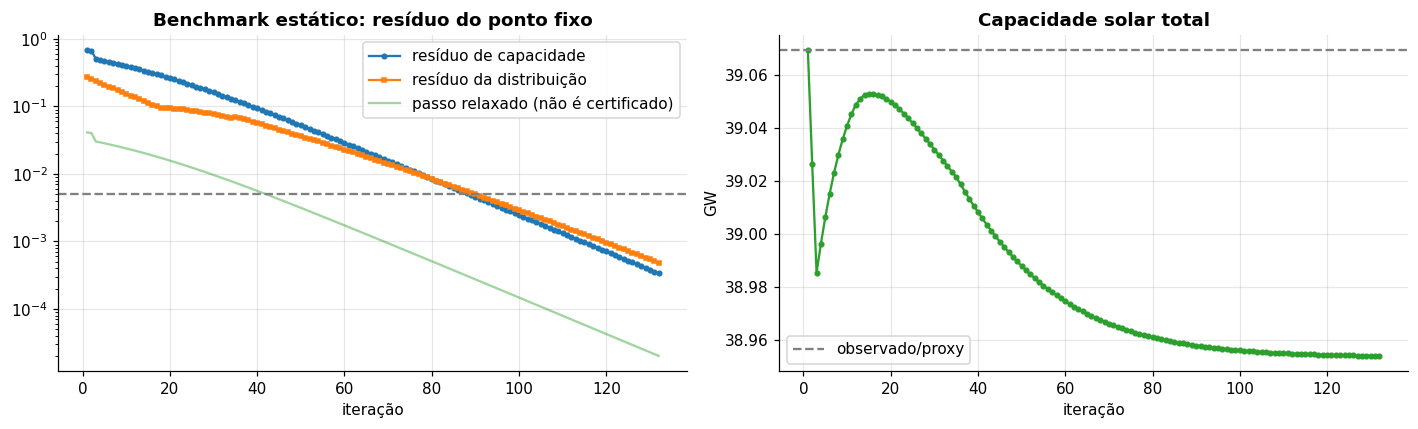

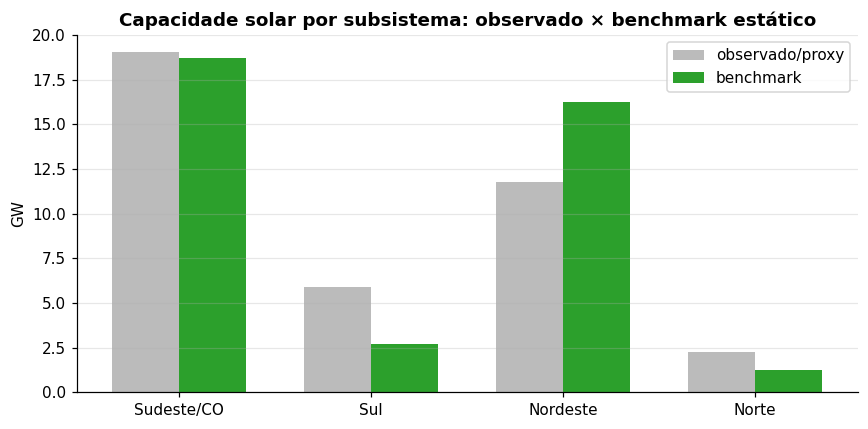

In [45]:
hist = mfg["hist"]
if not hist.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].semilogy(hist["it"], hist["residual_C"], marker="o", ms=3,
                     label="resíduo de capacidade")
    axes[0].semilogy(hist["it"], hist["residual_m"], marker="s", ms=3,
                     label="resíduo da distribuição")
    axes[0].semilogy(hist["it"], hist["step_C"], alpha=0.45,
                     label="passo relaxado (não é certificado)")
    axes[0].axhline(TOL_C_FP, ls="--", c="grey")
    axes[0].set_title("Benchmark estático: resíduo do ponto fixo")
    axes[0].set_xlabel("iteração"); axes[0].grid(alpha=0.3); axes[0].legend()
    axes[1].plot(hist["it"], hist["K_total_GW"], marker="o", ms=3, color="#2ca02c")
    axes[1].axhline(K_SOLAR_TOTAL_OBS / 1000, ls="--", c="grey", label="observado/proxy")
    axes[1].set_title("Capacidade solar total")
    axes[1].set_xlabel("iteração"); axes[1].set_ylabel("GW")
    axes[1].grid(alpha=0.3); axes[1].legend()
    fig.tight_layout(); fig.savefig(FIG_DIR / "mfg_convergencia.png", bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = eq.groupby("loc", as_index=False).agg(K_MFG_GW=("K_GW", "sum"))
plot_df["K_obs_GW"] = plot_df["loc"].map(lambda s: K_SOLAR_OBS[s] / 1000)
plot_df = plot_df.set_index("loc").reindex(SUBSYS_ORDER).reset_index()
idx = np.arange(len(plot_df)); width = 0.35
ax.bar(idx - width / 2, plot_df["K_obs_GW"], width, label="observado/proxy", color="#bbbbbb")
ax.bar(idx + width / 2, plot_df["K_MFG_GW"], width, label="benchmark", color="#2ca02c")
ax.set_xticks(idx); ax.set_xticklabels([SUB_LABEL[s] for s in plot_df["loc"]])
ax.set_title("Capacidade solar por subsistema: observado × benchmark estático")
ax.set_ylabel("GW"); ax.grid(axis="y", alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "mfg_capacidade_por_subsistema.png", bbox_inches="tight")
plt.show()



## 8. Contrafactual de capacidade fixa e ótimo social × benchmark privado

Três objetos são mantidos separados:

1. o **benchmark privado calibrado**, no qual agentes tomam a receita do clearing
   como dada;
2. o **contrafactual de capacidade total fixa**, que impõe
   $\sum_\ell K_\ell=K^{obs}$ e deixa o planejador apenas realocar essa capacidade;
3. o **ótimo social com total livre**, no qual capacidade e despacho são escolhidos
   conjuntamente, mas cada região respeita o limite numérico declarado
   $K_\ell\leq 3K^{obs}_\ell$.

O segundo objeto recupera a ideia de “orçamento fixo” do relatório antigo, mas com
uma correção importante: ele é apresentado como contrafactual controlado de
realocação, não como equilíbrio privado. O planejador usa o mesmo clearing físico
do setor privado; por isso a comparação identifica externalidades de preço,
congestionamento, curtailment e uso intertemporal da água sem trocar o modelo de
operação. Ela não implica causalidade empírica e continua condicionada às proxies
de custos, rede, hidrologia e dias representativos.


Ótimos sociais resolvidos em 1.4s | livre=optimal | total fixo=optimal
  loc  K_obs_GW  K_fixed_budget_GW  K_mfg_private_GW  K_social_GW  private_minus_social_GW
   SE    19.077             19.327            18.749       51.234                  -32.486
    S     5.919              0.000             2.698        5.568                   -2.870
   NE    11.789             19.742            16.234       22.058                   -5.824
    N     2.284              0.000             1.273        1.904                   -0.630
TOTAL    39.069             39.069            38.954       80.764                  -41.810


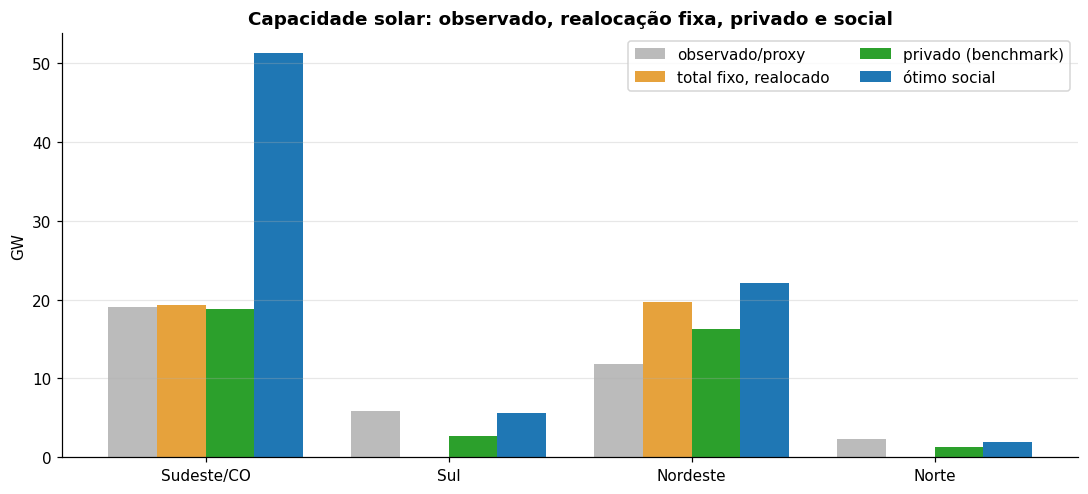

In [46]:
def solve_social_planner(total_capacity_MW=None, verbose=False):
    D_, L_, T_ = load.shape
    p = PARAMS
    K = cp.Variable(L_, nonneg=True)
    g_solar = cp.Variable((D_, L_, T_), nonneg=True)
    curt_solar = cp.Variable((D_, L_, T_), nonneg=True)
    g_wind = cp.Variable((D_, L_, T_), nonneg=True)
    curt_wind = cp.Variable((D_, L_, T_), nonneg=True)
    g_hydro = cp.Variable((D_, L_, T_), nonneg=True)
    spill = cp.Variable((D_, L_, T_), nonneg=True)
    storage = cp.Variable((D_, L_, T_ + 1), nonneg=True)
    g_th = cp.Variable((D_, L_, N_BLOCKS_TH, T_), nonneg=True)
    deficit = cp.Variable((D_, L_, T_), nonneg=True)
    flow = cp.Variable((D_, N_EDGES, T_))
    constraints, objective = [], 0

    for i, s in enumerate(LOCS):
        constraints += [K[i] <= 3.0 * max(K_SOLAR_OBS[s], 1.0)]
        objective += q_base[s] * K[i]

    if total_capacity_MW is not None:
        constraints += [cp.sum(K) == float(total_capacity_MW)]

    for d in range(D_):
        weight = float(weights[d])
        solar_potential = cp.multiply(cf_solar[d], cp.reshape(K, (L_, 1), order="C"))
        constraints += [
            g_solar[d] + curt_solar[d] == solar_potential,
            g_wind[d] + curt_wind[d] == wind_avail[d] * p["wind_scale"],
        ]
        objective += weight * p["curtail_penalty_solar"] * cp.sum(curt_solar[d])
        objective += weight * p["curtail_penalty_wind"] * cp.sum(curt_wind[d])
        objective += weight * p["deficit_penalty"] * cp.sum(deficit[d])
        objective += weight * p["water_opportunity_cost"] * cp.sum(g_hydro[d])

        for i, s in enumerate(LOCS):
            s0 = float(p["reservoir_initial_fraction"] * reservoir_capacity[i])
            constraints += [
                storage[d, i, :] <= reservoir_capacity[i],
                storage[d, i, 0] == s0,
                storage[d, i, -1] == s0,
                g_hydro[d, i, :] <= K_HYDRO[s],
                storage[d, i, 1:] == storage[d, i, :-1] + hydro_inflow[d, i, :]
                - g_hydro[d, i, :] - spill[d, i, :],
            ]
            gth_total = cp.sum(g_th[d, i, :, :], axis=0)
            objective += weight * p["thermal_ramp_penalty"] * cp.sum_squares(
                gth_total[1:] - gth_total[:-1])
            for block in range(N_BLOCKS_TH):
                constraints += [g_th[d, i, block, :] <= THERM_CAP[i, block]]
                objective += weight * THERM_COST[i, block] * p["thermal_cost_mult"] * cp.sum(
                    g_th[d, i, block, :])
                objective += weight * 0.5 * p["thermal_quad"] * cp.sum_squares(
                    g_th[d, i, block, :])

        for edge in range(N_EDGES):
            constraints += [flow[d, edge, :] <= FMAX[edge], flow[d, edge, :] >= -FMAX[edge]]
        hub_net_import = 0
        for edge, (origin, destination) in enumerate(EDGES):
            if destination == HUB:
                hub_net_import += flow[d, edge, :]
            if origin == HUB:
                hub_net_import -= flow[d, edge, :]
        constraints += [hub_net_import == 0]

        for i, loc in enumerate(LOCS):
            net_import = 0
            for edge, (origin, destination) in enumerate(EDGES):
                if destination == loc:
                    net_import += flow[d, edge, :]
                if origin == loc:
                    net_import -= flow[d, edge, :]
            generation = (
                g_solar[d, i, :] + g_wind[d, i, :] + g_hydro[d, i, :]
                + cp.sum(g_th[d, i, :, :], axis=0) + nuc_avail[d, i, :]
                + net_import + deficit[d, i, :]
            )
            constraints += [load[d, i, :] * p["demand_scale"] - generation == 0]

    tik = float(p.get("clearing_tikhonov", 0.0))
    if tik > 0:
        objective += tik * (
            cp.sum_squares(g_solar) + cp.sum_squares(g_wind)
            + cp.sum_squares(g_hydro) + cp.sum_squares(deficit) + cp.sum_squares(g_th))
    problem = cp.Problem(cp.Minimize(objective), constraints)
    solved, errors = False, []
    for solver, kwargs in [
        ("CLARABEL", {"max_iter": 2200}),
        ("OSQP", {"eps_abs": 1e-5, "eps_rel": 1e-5, "max_iter": 18000, "polishing": True}),
        ("SCS", {"eps": 1e-3, "max_iters": 12000}),
    ]:
        try:
            if solver in cp.installed_solvers():
                problem.solve(solver=solver, warm_start=True, verbose=verbose, **kwargs)
                if problem.status == "optimal":
                    solved = True
                    break
                errors.append((solver, f"status={problem.status}"))
        except Exception as exc:
            errors.append((solver, repr(exc)))
    if not solved:
        raise RuntimeError(f"Ótimo social não resolveu com status optimal: {errors}")
    return {"status": problem.status, "K_social": np.maximum(np.asarray(K.value, float), 0.0)}


if RUN_SOCIAL_PLANNER:
    t0 = time.time()
    social = solve_social_planner()
    fixed_budget = solve_social_planner(total_capacity_MW=K_SOLAR_TOTAL_OBS)
    print(f"Ótimos sociais resolvidos em {time.time()-t0:.1f}s | "
          f"livre={social['status']} | total fixo={fixed_budget['status']}")

    K_mfg_loc = {s: sum(mfg["K_by_type"][s][agent_type]
                         for agent_type in AGENT_TYPES) for s in LOCS}
    comp = pd.DataFrame([{
        "loc": s,
        "K_obs_GW": K_SOLAR_OBS[s] / 1000,
        "K_fixed_budget_GW": fixed_budget["K_social"][i] / 1000,
        "K_mfg_private_GW": K_mfg_loc[s] / 1000,
        "K_social_GW": social["K_social"][i] / 1000,
        "private_minus_social_GW": (K_mfg_loc[s] - social["K_social"][i]) / 1000,
    } for i, s in enumerate(LOCS)])
    total_row = {"loc": "TOTAL"}
    for column in ["K_obs_GW", "K_fixed_budget_GW", "K_mfg_private_GW",
                   "K_social_GW", "private_minus_social_GW"]:
        total_row[column] = float(comp[column].sum())
    comp = pd.concat([comp, pd.DataFrame([total_row])], ignore_index=True)
    comp.to_csv(TABLE_DIR / "private_vs_social_capacity.csv", index=False)
    comp[["loc", "K_obs_GW", "K_fixed_budget_GW"]].to_csv(
        TABLE_DIR / "fixed_budget_capacity.csv", index=False)
    print(comp.round(3).to_string(index=False))

    plot_c = comp[comp["loc"] != "TOTAL"].set_index("loc").reindex(SUBSYS_ORDER)
    fig, ax = plt.subplots(figsize=(10, 4.6))
    idx = np.arange(len(plot_c)); width = 0.20
    ax.bar(idx - 1.5 * width, plot_c["K_obs_GW"], width,
           label="observado/proxy", color="#bbbbbb")
    ax.bar(idx - 0.5 * width, plot_c["K_fixed_budget_GW"], width,
           label="total fixo, realocado", color="#e6a23c")
    ax.bar(idx + 0.5 * width, plot_c["K_mfg_private_GW"], width,
           label="privado (benchmark)", color="#2ca02c")
    ax.bar(idx + 1.5 * width, plot_c["K_social_GW"], width,
           label="ótimo social", color="#1f77b4")
    ax.set_xticks(idx); ax.set_xticklabels([SUB_LABEL[s] for s in plot_c.index])
    ax.set_title("Capacidade solar: observado, realocação fixa, privado e social")
    ax.set_ylabel("GW"); ax.grid(axis="y", alpha=0.3); ax.legend(ncol=2)
    fig.tight_layout(); fig.savefig(FIG_DIR / "privado_vs_social.png", bbox_inches="tight")
    plt.show()
else:
    print("RUN_SOCIAL_PLANNER=False; ótimo social não executado.")


### Leitura locacional do total fixo

Com o total preso em 39,069 GW, o planejador leva a capacidade para SE e NE porque
esses nós combinam menor custo anualizado, produtividade, acesso à maior carga e a
interface direta NE--SE. Sul e Norte ficam próximos de zero porque são periféricos
na rede reduzida e têm custo de referência maior. É uma solução de canto do modelo:
não existem piso regional, benefício de diversificação, risco de extremos, limites
locais de conexão ou valor de expansão futura da rede. O gráfico do relatório deve
ser lido como diagnóstico dessas hipóteses, não como recomendação de desinvestimento.


## 9. Leitura econômica, escopo e limitações

O notebook contém agora três níveis deliberadamente distintos:

1. um **laboratório finito** de incumbente e entrante;
2. um **benchmark estático reduzido**, útil para calibração e comparação privada;
3. um **MFG dinâmico integrado**, com Bellman, realocação, forward e clearing.

O reservatório é intertemporal dentro de cada medoide, com fechamento cíclico. Isso
é mais rigoroso que um orçamento diário, mas não substitui uma árvore cronológica
sazonal. Os três blocos térmicos são uma curva de mérito reduzida; o hub `I` usa
limites fixos; e o custo da água continua sendo objeto de sensibilidade.

No benchmark estático, a grade é apenas uma representação baricêntrica de uma
escolha contínua. No MFG dinâmico, `DYN_TAU_RS>0` define explicitamente um
**equilíbrio entrópico regularizado**. Com `DYN_TAU_RS=0`, o código usa a
correspondência de melhores respostas exatas, dividindo massa apenas entre ações
empatadas numericamente. Os dois objetos não devem ser confundidos.

**Extensão prioritária — contratos.** O `premium` resume receita não spot em um
número calibrado. Contratos futuros devem ser representados por volume, preço,
prazo, perfil e penalidades.


## 10. MFG dinâmico integrado — capacidade, localização e distribuição

Esta seção implementa o objeto completo. O estado anual é
$x=(\ell,\theta,b)$; a ação escolhe simultaneamente
$a=(\ell',\Delta b)$; e o tipo $\theta$ é permanente. Para uma trajetória de
receitas gerada pelo clearing, o agente resolve

$$V_t(x)=\tau\log\sum_{a\in\mathcal A(x)}
\exp\left(\frac{r_t(x,a;m_t,R_t)+\beta V_{t+1}(x')}{\tau}\right).$$

Quando $\tau=0$, a expressão vira o máximo de Bellman e a política divide
probabilidade somente entre ações realmente empatadas. Quando $\tau>0$, o modelo é
um MFG entrópico regularizado, nomeado dessa forma sem alegar equivalência ao jogo
não regularizado.

Os agentes não colapsam todos em um único caminho porque o destino não tem valor
fixo. A receita local cai quando a massa e a capacidade solar crescem; a penalidade
de concentração aumenta com a participação do destino; mudar de região e ajustar o
porte têm custo; e os tipos `high` e `low` carregam produtividade e custo distintos.
Com $\tau>0$, ações de valor próximo também mantêm probabilidade positiva. Essa
construção representa, de forma estilizada, heterogeneidade de projetos, custos
afundados, restrições de conexão e incerteza entre alternativas próximas — razões
pelas quais investimentos reais não convergem instantaneamente para o mesmo lugar.

A distribuição evolui por

$$m_{t+1}(x')=\sum_x\sum_a m_t(x)\pi_t(a\mid x)
\mathbf 1\{T(x,a)=x'\}.$$

Em cada estágio, $m_t$ determina a capacidade locacional, o clearing devolve
$R_t$, o Bellman devolve $\pi_t$, e a equação forward devolve uma nova trajetória
de distribuições. O equilíbrio é o ponto fixo dessa trajetória inteira.


In [47]:
DYN_K_MW = np.arange(DYN_MAX_BIN + 1, dtype=float) * DYN_CAP_UNIT_MW
DYN_N_BINS = len(DYN_K_MW)
DYN_N_TYPES = len(AGENT_TYPES)
DYN_N_AGENTS = K_SOLAR_TOTAL_OBS / max(4.0 * DYN_CAP_UNIT_MW, 1e-9)

dyn_m0 = np.zeros((N_LOC, DYN_N_TYPES, DYN_N_BINS), float)
for li, loc in enumerate(LOCS):
    for ti, agent_type in enumerate(AGENT_TYPES):
        dyn_m0[li, ti, 4] = p_loc[loc] * TYPE_WEIGHT[agent_type]
dyn_m0 /= dyn_m0.sum()


def dynamic_capacity_by_type(m_stage: np.ndarray) -> dict[str, dict[str, float]]:
    return {
        loc: {
            agent_type: float(
                DYN_N_AGENTS * np.sum(m_stage[li, ti, :] * DYN_K_MW))
            for ti, agent_type in enumerate(AGENT_TYPES)
        }
        for li, loc in enumerate(LOCS)
    }


def dynamic_capacity_matrix(m_path: np.ndarray) -> np.ndarray:
    out = np.zeros((len(m_path), N_LOC), float)
    for stage in range(len(m_path)):
        cap = dynamic_capacity_by_type(m_path[stage])
        for li, loc in enumerate(LOCS):
            out[stage, li] = sum(cap[loc].values())
    return out


_dynamic_clear_cache = {}


def dynamic_clearing_path(m_path: np.ndarray):
    R_path = np.zeros((DYN_HORIZON, N_LOC, DYN_N_TYPES), float)
    clearings = []
    for stage in range(DYN_HORIZON):
        capacity = dynamic_capacity_by_type(m_path[stage])
        key = tuple(round(capacity[loc][agent_type], 5)
                    for loc in LOCS for agent_type in AGENT_TYPES)
        if key not in _dynamic_clear_cache:
            _dynamic_clear_cache[key] = engine.solve(capacity)
        clearing = _dynamic_clear_cache[key]
        clearings.append(clearing)
        for li, loc in enumerate(LOCS):
            for ti, agent_type in enumerate(AGENT_TYPES):
                R_path[stage, li, ti] = clearing["R"][(loc, agent_type)]
    return R_path, clearings


def _logsumexp(values: np.ndarray, tau: float) -> float:
    vmax = float(np.max(values))
    return vmax + tau * float(np.log(np.exp((values - vmax) / tau).sum()))


def solve_dynamic_bellman(R_path: np.ndarray, m_path: np.ndarray, tau: float = DYN_TAU_RS):
    value = np.zeros((DYN_HORIZON + 1, N_LOC, DYN_N_TYPES, DYN_N_BINS), float)
    policy = np.zeros((DYN_HORIZON, N_LOC, DYN_N_TYPES, DYN_N_BINS,
                       N_LOC, len(DYN_DELTA_BINS)), float)

    for stage in range(DYN_HORIZON - 1, -1, -1):
        loc_share = m_path[stage].sum(axis=(1, 2))
        for li, loc_from in enumerate(LOCS):
            for ti, agent_type in enumerate(AGENT_TYPES):
                for bi, K_from in enumerate(DYN_K_MW):
                    candidates = []
                    indices = []
                    for lj, loc_to in enumerate(LOCS):
                        for di, delta in enumerate(DYN_DELTA_BINS):
                            bj = bi + delta
                            if bj < 0 or bj >= DYN_N_BINS:
                                continue
                            K_to = float(DYN_K_MW[bj])
                            margin = (R_path[stage, lj, ti] + PREMIUM_STAR
                                      - q_type[(loc_to, agent_type)])
                            operating_profit = margin * K_to
                            adjustment = 0.5 * DYN_ADJUSTMENT_RS_MW2 * (K_to - K_from) ** 2
                            entry = DYN_ENTRY_COST_RS if bi == 0 and bj > 0 else 0.0
                            moving = DYN_MOVE_COST_RS if li != lj else 0.0
                            concentration = (DYN_CONCENTRATION_RS * loc_share[lj]
                                             * (K_to / 1000.0) ** 2)
                            reward = operating_profit - adjustment - entry - moving - concentration
                            q_value = reward + DYN_BETA * value[stage + 1, lj, ti, bj]
                            candidates.append(q_value)
                            indices.append((lj, di, bj))

                    q_values = np.asarray(candidates, float)
                    if tau > 0:
                        q_max = float(q_values.max())
                        probabilities = np.exp(np.clip((q_values - q_max) / tau, -80, 0))
                        probabilities /= probabilities.sum()
                        value[stage, li, ti, bi] = _logsumexp(q_values, tau)
                    else:
                        q_max = float(q_values.max())
                        winners = np.isclose(q_values, q_max, rtol=1e-10, atol=1e-6)
                        probabilities = winners.astype(float) / winners.sum()
                        value[stage, li, ti, bi] = q_max
                    for probability, (lj, di, _bj) in zip(probabilities, indices):
                        policy[stage, li, ti, bi, lj, di] = probability
    return value, policy


def dynamic_forward(policy: np.ndarray) -> np.ndarray:
    # H decisões geram H+1 distribuições, incluindo o estado terminal m_H.
    m_forward = np.zeros((DYN_HORIZON + 1, N_LOC, DYN_N_TYPES, DYN_N_BINS), float)
    m_forward[0] = dyn_m0
    for stage in range(DYN_HORIZON):
        for li in range(N_LOC):
            for ti in range(DYN_N_TYPES):
                for bi in range(DYN_N_BINS):
                    mass = m_forward[stage, li, ti, bi]
                    if mass <= 0:
                        continue
                    for lj in range(N_LOC):
                        for di, delta in enumerate(DYN_DELTA_BINS):
                            probability = policy[stage, li, ti, bi, lj, di]
                            if probability <= 0:
                                continue
                            bj = bi + delta
                            if 0 <= bj < DYN_N_BINS:
                                m_forward[stage + 1, lj, ti, bj] += mass * probability
        m_forward[stage + 1] /= m_forward[stage + 1].sum()
    return m_forward


def solve_dynamic_mfg(progress=True):
    m_path = np.repeat(dyn_m0[None, ...], DYN_HORIZON + 1, axis=0)
    history = []
    iterator = range(1, DYN_MAX_ITER + 1)
    if progress:
        iterator = tqdm(iterator, desc="MFG dinâmico", leave=False)

    for iteration in iterator:
        R_path, clearings = dynamic_clearing_path(m_path)
        value, policy = solve_dynamic_bellman(R_path, m_path, tau=DYN_TAU_RS)
        forward_path = dynamic_forward(policy)
        residual_m = float(np.max(np.abs(forward_path - m_path)))
        current_capacity = dynamic_capacity_matrix(m_path)
        forward_capacity = dynamic_capacity_matrix(forward_path)
        residual_C = float(np.max(
            np.abs(forward_capacity - current_capacity) / (current_capacity + 1.0)))
        history.append({
            "it": iteration, "residual_m": residual_m, "residual_C": residual_C,
            "step_m": DYN_RELAXATION * residual_m,
            "K_initial_GW": current_capacity[0].sum() / 1000,
            "K_terminal_GW": current_capacity[-1].sum() / 1000,
        })
        if progress:
            iterator.set_postfix({"res_m": f"{residual_m:.1e}",
                                  "res_C": f"{residual_C:.1e}"})
        if residual_m < DYN_TOL_M and residual_C < DYN_TOL_C:
            break
        m_path = (1.0 - DYN_RELAXATION) * m_path + DYN_RELAXATION * forward_path
        m_path[0] = dyn_m0
        m_path /= m_path.sum(axis=(1, 2, 3), keepdims=True)

    # Certificado final no operador não relaxado.
    R_path, clearings = dynamic_clearing_path(m_path)
    value, policy = solve_dynamic_bellman(R_path, m_path, tau=DYN_TAU_RS)
    forward_path = dynamic_forward(policy)
    residual_m = float(np.max(np.abs(forward_path - m_path)))
    current_capacity = dynamic_capacity_matrix(m_path)
    forward_capacity = dynamic_capacity_matrix(forward_path)
    residual_C = float(np.max(
        np.abs(forward_capacity - current_capacity) / (current_capacity + 1.0)))
    R_forward, _ = dynamic_clearing_path(forward_path)
    residual_R = float(np.max(np.abs(R_forward - R_path) / (np.abs(R_path) + 1.0)))
    certified = bool(
        residual_m < DYN_TOL_M and residual_C < DYN_TOL_C and residual_R < DYN_TOL_R)
    return {
        "m": m_path, "forward": forward_path, "R": R_path,
        "clearings": clearings, "value": value, "policy": policy,
        "history": pd.DataFrame(history), "nit": iteration,
        "residual_m": residual_m, "residual_C": residual_C,
        "residual_R": residual_R, "certified": certified,
    }


t0 = time.time()
dynamic_mfg = solve_dynamic_mfg(progress=True)
print(
    f"MFG dinâmico certificado={dynamic_mfg['certified']} em {dynamic_mfg['nit']} iterações | "
    f"r_m={dynamic_mfg['residual_m']:.2e}, r_C={dynamic_mfg['residual_C']:.2e}, "
    f"r_R={dynamic_mfg['residual_R']:.2e} | tempo={(time.time()-t0)/60:.1f} min")
if not dynamic_mfg["certified"]:
    print("AVISO: resultados dinâmicos são aproximações; o rótulo de equilíbrio certificado "
          "permanece falso até os resíduos não relaxados atingirem as tolerâncias.")

assert np.allclose(dynamic_mfg["m"].sum(axis=(1, 2, 3)), 1.0)
assert np.allclose(dynamic_mfg["policy"].sum(axis=(4, 5)), 1.0)


MFG dinâmico certificado=True em 67 iterações | r_m=2.00e-04, r_C=2.19e-04, r_R=2.61e-06 | tempo=0.5 min


### 10.1 Auditoria do ponto fixo, política e trajetória forward

As tabelas abaixo tornam os três objetos verificáveis separadamente:

- `dynamic_mfg_distribution.csv`: trajetória proposta de $m_t$;
- `dynamic_mfg_policy.csv`: política longa $\pi_t(a\mid x)$, uma linha por ação;
- `dynamic_mfg_policy_summary.csv`: momentos e ação modal por estado;
- `dynamic_mfg_path.csv`: capacidade, preços e massa por estágio/local;
- `dynamic_mfg_convergence.csv`: resíduos **não relaxados** do operador.

A política probabilística é parte do modelo quando $\tau>0$; não é ruído
adicionado depois. A figura de convergência separa o resíduo verdadeiro do tamanho
do passo numérico.


,stage,loc,mass,capacity_MW,R_high_RS_MW_ano,R_low_RS_MW_ano,lambda_mean_RS_MWh,solar_curt_MWh_weighted
0,0,SE,0.488,19077.048,685726.359,596835.905,274.965,0.001
1,0,S,0.151,5918.671,569085.820,495315.436,275.336,0.001
2,0,NE,0.302,11789.296,764159.272,665101.588,274.961,0.001
3,0,N,0.058,2284.276,666658.588,580239.882,271.890,0.001
4,1,SE,0.489,21156.265,624479.193,543528.186,256.007,0.002
5,1,S,0.120,4892.827,543131.928,472725.937,276.958,0.002
6,1,NE,0.339,15011.779,691735.294,602065.904,255.929,0.002
7,1,N,0.052,2160.408,606956.391,528276.859,253.098,0.002
8,2,SE,0.488,22821.688,623487.742,542665.257,255.789,0.005
9,2,S,0.105,4345.357,542846.978,472477.925,276.895,0.006


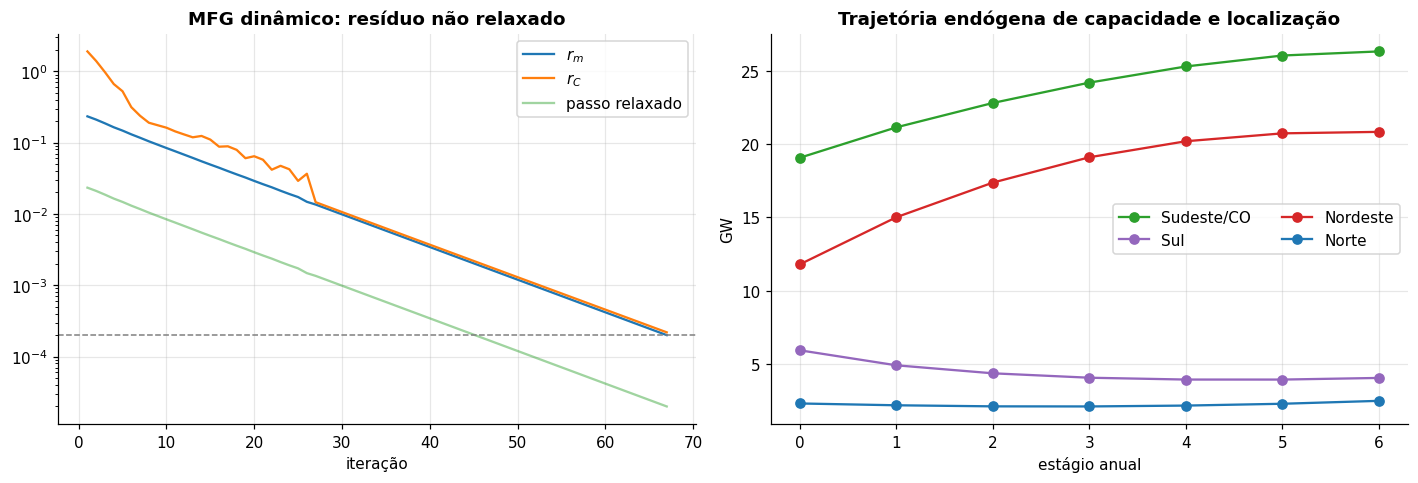

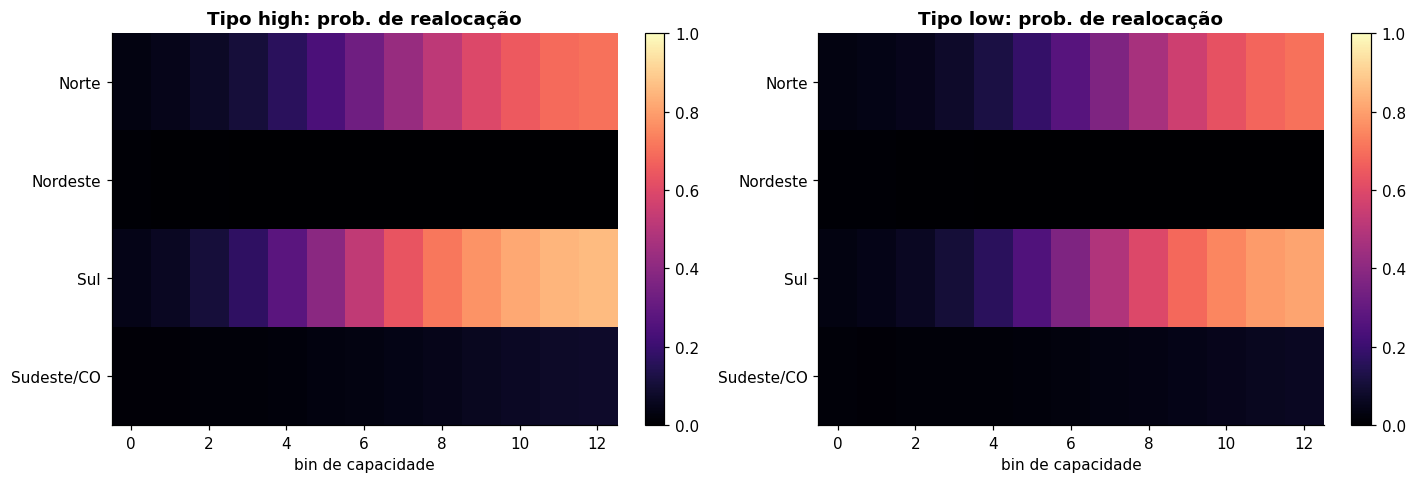

In [48]:
dynamic_mfg["history"].to_csv(TABLE_DIR / "dynamic_mfg_convergence.csv", index=False)

distribution_rows = []
path_rows = []
capacity_path = dynamic_capacity_matrix(dynamic_mfg["m"])
for stage in range(DYN_HORIZON + 1):
    clearing = dynamic_mfg["clearings"][stage] if stage < DYN_HORIZON else None
    diag = clearing["diagnostics"] if clearing is not None else None
    for li, loc in enumerate(LOCS):
        mass_loc = float(dynamic_mfg["m"][stage, li].sum())
        path_rows.append({
            "stage": stage, "loc": loc, "mass": mass_loc,
            "capacity_MW": capacity_path[stage, li],
            "R_high_RS_MW_ano": (dynamic_mfg["R"][stage, li, AGENT_TYPES.index("high")]
                                   if stage < DYN_HORIZON else np.nan),
            "R_low_RS_MW_ano": (dynamic_mfg["R"][stage, li, AGENT_TYPES.index("low")]
                                  if stage < DYN_HORIZON else np.nan),
            "lambda_mean_RS_MWh": (float(diag.loc[diag["loc"] == loc, "lambda_mean"].mean())
                                      if diag is not None else np.nan),
            "solar_curt_MWh_weighted": (float(
                (diag.loc[diag["loc"] == loc, "solar_curt_MWh_day"]
                 * diag.loc[diag["loc"] == loc, "weight_days"]).sum())
                if diag is not None else np.nan),
        })
        for ti, agent_type in enumerate(AGENT_TYPES):
            for bi, K_agent in enumerate(DYN_K_MW):
                mass = float(dynamic_mfg["m"][stage, li, ti, bi])
                distribution_rows.append({
                    "stage": stage, "loc": loc, "type": agent_type,
                    "bin": bi, "K_agent_MW": K_agent, "mass": mass,
                    "aggregate_capacity_MW": DYN_N_AGENTS * mass * K_agent,
                })

dynamic_path = pd.DataFrame(path_rows)
dynamic_distribution = pd.DataFrame(distribution_rows)
dynamic_path.to_csv(TABLE_DIR / "dynamic_mfg_path.csv", index=False)
dynamic_distribution.to_csv(TABLE_DIR / "dynamic_mfg_distribution.csv", index=False)

policy_rows = []
policy_action_rows = []
for stage in range(DYN_HORIZON):
    for li, loc_from in enumerate(LOCS):
        for ti, agent_type in enumerate(AGENT_TYPES):
            for bi, K_from in enumerate(DYN_K_MW):
                probabilities = dynamic_mfg["policy"][stage, li, ti, bi]
                relocation_probability = 0.0
                expected_delta_MW = 0.0
                modal = np.unravel_index(np.argmax(probabilities), probabilities.shape)
                modal_lj, modal_di = modal
                for lj in range(N_LOC):
                    for di, delta in enumerate(DYN_DELTA_BINS):
                        probability = probabilities[lj, di]
                        target_bin = bi + delta
                        if 0 <= target_bin < DYN_N_BINS:
                            policy_action_rows.append({
                                "stage": stage, "type": agent_type,
                                "loc_current": loc_from, "bin_current": bi,
                                "K_current_MW": K_from, "loc_next": LOCS[lj],
                                "delta_bin": delta, "bin_next": target_bin,
                                "K_next_MW": DYN_K_MW[target_bin],
                                "probability": probability,
                            })
                        if lj != li:
                            relocation_probability += probability
                        expected_delta_MW += probability * delta * DYN_CAP_UNIT_MW
                modal_b = bi + DYN_DELTA_BINS[modal_di]
                policy_rows.append({
                    "stage": stage, "type": agent_type,
                    "loc_current": loc_from, "bin_current": bi, "K_current_MW": K_from,
                    "expected_delta_MW": expected_delta_MW,
                    "relocation_probability": relocation_probability,
                    "modal_loc_next": LOCS[modal_lj], "modal_bin_next": modal_b,
                    "modal_K_next_MW": DYN_K_MW[modal_b],
                    "modal_probability": probabilities[modal_lj, modal_di],
                })
dynamic_policy = pd.DataFrame(policy_rows)
dynamic_policy_actions = pd.DataFrame(policy_action_rows)
dynamic_policy_actions.to_csv(TABLE_DIR / "dynamic_mfg_policy.csv", index=False)
dynamic_policy.to_csv(TABLE_DIR / "dynamic_mfg_policy_summary.csv", index=False)

# Trajetórias modais servem apenas à leitura individual; o objeto do MFG continua m_t.
modal_path_rows = []
for agent_type in AGENT_TYPES:
    ti = AGENT_TYPES.index(agent_type)
    for initial_loc in LOCS:
        li, bi = LOCS.index(initial_loc), 4
        for stage in range(DYN_HORIZON):
            probabilities = dynamic_mfg["policy"][stage, li, ti, bi]
            lj, di = np.unravel_index(np.argmax(probabilities), probabilities.shape)
            bj = bi + DYN_DELTA_BINS[di]
            modal_path_rows.append({
                "type": agent_type, "initial_loc": initial_loc, "stage": stage,
                "loc_current": LOCS[li], "K_current_MW": DYN_K_MW[bi],
                "loc_next": LOCS[lj], "K_next_MW": DYN_K_MW[bj],
                "action_probability": probabilities[lj, di],
            })
            li, bi = lj, bj
dynamic_modal_paths = pd.DataFrame(modal_path_rows)
dynamic_modal_paths.to_csv(TABLE_DIR / "dynamic_mfg_modal_paths.csv", index=False)

display(dynamic_path.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
history = dynamic_mfg["history"]
axes[0].semilogy(history["it"], history["residual_m"], label=r"$r_m$")
axes[0].semilogy(history["it"], history["residual_C"], label=r"$r_C$")
axes[0].semilogy(history["it"], history["step_m"], alpha=0.45,
                 label="passo relaxado")
axes[0].axhline(DYN_TOL_M, color="grey", ls="--", lw=1)
axes[0].set_title("MFG dinâmico: resíduo não relaxado")
axes[0].set_xlabel("iteração"); axes[0].grid(alpha=0.3); axes[0].legend()
for loc in LOCS:
    subset = dynamic_path[dynamic_path["loc"] == loc]
    axes[1].plot(subset["stage"], subset["capacity_MW"] / 1000,
                 marker="o", label=SUB_LABEL[loc], color=SUB_COLOR[loc])
axes[1].set_title("Trajetória endógena de capacidade e localização")
axes[1].set_xlabel("estágio anual"); axes[1].set_ylabel("GW")
axes[1].grid(alpha=0.3); axes[1].legend(ncol=2)
fig.tight_layout(); fig.savefig(FIG_DIR / "dynamic_mfg_convergence.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for agent_type, ax in zip(AGENT_TYPES, axes):
    subset = dynamic_policy[(dynamic_policy["stage"] == 0)
                            & (dynamic_policy["type"] == agent_type)]
    matrix = subset.pivot(index="loc_current", columns="bin_current",
                          values="relocation_probability").reindex(LOCS)
    image = ax.imshow(matrix.to_numpy(), aspect="auto", origin="lower", vmin=0, vmax=1,
                      cmap="magma")
    ax.set_yticks(range(N_LOC)); ax.set_yticklabels([SUB_LABEL[loc] for loc in LOCS])
    ax.set_xlabel("bin de capacidade"); ax.set_title(f"Tipo {agent_type}: prob. de realocação")
    fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout(); fig.savefig(FIG_DIR / "dynamic_mfg_policy.png", bbox_inches="tight")
plt.show()
